### Create a border class

In [2]:
import nibabel as nib
import numpy as np
from scipy.ndimage import binary_erosion, generate_binary_structure

def create_bone_borders(input_path, output_path, border_thickness=1):
    """
    Takes an Odd-Even mask and adds a Border class (5) for vertebrae.
    Class 1, 2 -> Vertebrae (Odd/Even)
    Class 3    -> IVD
    Class 4    -> Canal
    Class 5    -> NEW Border Class
    """
    print(f"Processing: {input_path}")
    
    # Load NIfTI
    img = nib.load(input_path)
    data = img.get_fdata().astype(np.uint16)
    
    # 1. Create a mask of all bone (Class 1 and Class 2)
    bone_mask = (data == 1) | (data == 2)
    
    if not np.any(bone_mask):
        print("No bone found in this file. Skipping.")
        return

    # 2. Generate the "Inner Border"
    # We erode the bone and subtract it from the original bone mask.
    # This ensures the border stays INSIDE the bone volume and doesn't 
    # bleed into the IVD (Class 3) or Canal (Class 4).
    struct = generate_binary_structure(3, 1) # 6-connectivity for clean edges
    eroded_bone = binary_erosion(bone_mask, structure=struct, iterations=border_thickness)
    
    # The border is the area that was removed during erosion
    border_mask = bone_mask & ~eroded_bone
    
    # 3. Update the data
    # Important: We only overwrite pixels that were originally Class 1 or 2
    new_data = np.copy(data)
    new_data[border_mask] = 5
    
    # 4. Save the result
    new_img = nib.Nifti1Image(new_data.astype(np.uint16), img.affine, img.header)
    nib.save(new_img, output_path)
    print(f"Saved with border class (5) to: {output_path}")

# Example Usage
INPUT = "../nnUNet_raw/Dataset102_SpiderOddEven/labelsTs/spider_191.nii.gz" # Use the original nnU-Net output!
OUTPUT = "predictions_real_test/with_border_class.nii.gz"
create_bone_borders(INPUT, OUTPUT, border_thickness=1)

Processing: ../nnUNet_raw/Dataset102_SpiderOddEven/labelsTs/spider_191.nii.gz
Saved with border class (5) to: predictions_real_test/with_border_class.nii.gz


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, generate_binary_structure, center_of_mass
from skimage.measure import regionprops
import nibabel as nib
from scipy.spatial import cKDTree

def visualize_spinal_territories(input_path, full_labeled_bones_arr, main_bodies_ids, z_axis=2, output_png_path='territory_viz.png', x_slice=None):
    print(f"Loading MRI for visualization: {input_path}")
    img = nib.load(input_path)
    mri_raw = img.get_fdata()
    # Normalize MRI for display contrast
    mri_data = (mri_raw - np.min(mri_raw)) / (np.max(mri_raw) - np.min(mri_raw))

    # --- Step 1: Pre-computations ---
    # Centroids for Main Bodies
    props = regionprops(full_labeled_bones_arr)
    mb_centroids = {p.label: np.array(p.centroid) for p in props}
    
    # Label Intervertebral Discs (Label 3)
    ivd_mask = (mri_raw.astype(np.uint16) == 3)
    struct_join = generate_binary_structure(3, 2) 
    labeled_ivds, _ = label(ivd_mask, structure=struct_join)
    ivd_centroids = np.array([p.centroid for p in regionprops(labeled_ivds)])

    ivd_props = regionprops(labeled_ivds)
    ivd_data = {p.label: np.array(p.centroid) for p in ivd_props}

    print("Extracting Spinal Canal Centerline...")
    canal_mask = (mri_raw.astype(np.uint16) == 4)

    # Get all unique Z-slices where the canal exists
    # Assuming z_axis=0 for the array dimensions (Z, Y, X)
    z_indices = np.unique(np.argwhere(canal_mask)[:, z_axis])

    centerline_pts = []
    for z in z_indices:
        slice_mask = canal_mask[:, :, z]
        if np.any(slice_mask):
            # Find 2D centroid of the canal in this slice
            x, y = center_of_mass(slice_mask)
            centerline_pts.append([x, y, z])

    # Convert to a NumPy array for fast vectorized distance calculations
    centerline_pts = np.array(centerline_pts)

    canal_tree = cKDTree(centerline_pts)

    # Initialize 3D Territory Volume
    territory_volume = np.zeros_like(full_labeled_bones_arr, dtype=np.uint16)
    
    # Optimization: Only calculate math for the spine's bounding box
    mask_indices = np.argwhere((full_labeled_bones_arr > 0) | (ivd_mask))
    min_c, max_c = mask_indices.min(axis=0), mask_indices.max(axis=0)
    z_c, y_c, x_c = np.mgrid[min_c[0]:max_c[0], min_c[1]:max_c[1], min_c[2]:max_c[2]]
    grid_coords = np.vstack([z_c.ravel(), y_c.ravel(), x_c.ravel()]).T

    mb_boundary_data = {}

    print("Calculating 3D territory and boundaries...")
    for mb_id in main_bodies_ids:
        if mb_id not in mb_centroids: continue
        mb_c = mb_centroids[mb_id]
        z_idx = z_axis
        # Find nearest discs above/below
        above_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_idx] < mb_c[z_idx]}
        below_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_idx] > mb_c[z_idx]}

        local_axis = np.array([0.0, 0.0, 1.0]) # Default straight Z
        b_upper, b_lower = mb_c[z_idx] - 15, mb_c[z_idx] + 15 

        c_upper, c_lower = None, None

        if above_candidates and below_candidates:
            # c_upper = ivds_above[np.argmin(np.linalg.norm(ivds_above - mb_c, axis=1))]
            # c_lower = ivds_below[np.argmin(np.linalg.norm(ivds_below - mb_c, axis=1))]

            # Find the label of the nearest disc above
            upper_lbl = min(above_candidates, key=lambda k: np.linalg.norm(above_candidates[k] - mb_c))
            upper_coords = np.argwhere(labeled_ivds == upper_lbl)
            
            # THE CANAL FIX: Query the KDTree. 
            # 'distances' is the distance from each disc voxel to the nearest canal point.
            distances, _ = canal_tree.query(upper_coords)
            
            # The anchor point is the disc voxel with the smallest distance to the canal
            c_upper = upper_coords[np.argmin(distances)]
            b_upper = np.dot(c_upper, local_axis)

            lower_lbl = min(below_candidates, key=lambda k: np.linalg.norm(below_candidates[k] - mb_c))
            lower_coords = np.argwhere(labeled_ivds == lower_lbl)
            
            # THE CANAL FIX: Find closest voxel to the spinal canal
            distances, _ = canal_tree.query(lower_coords)
            
            # The anchor point is the disc voxel with the smallest distance to the canal
            c_lower = lower_coords[np.argmin(distances)]
            b_lower = np.dot(c_lower, local_axis)
            
            # # Local Spine Axis
            # vector_spine = c_lower - c_upper
            # norm = np.linalg.norm(vector_spine)
            # local_axis = vector_spine / norm if norm > 0 else np.array([1.0, 0.0, 0.0])
            
            # # Plane boundaries
            # b_upper = np.dot(c_upper, local_axis)
            # b_lower = np.dot(c_lower, local_axis)

            # 2. DEFINE THE LOCAL SPINE AXIS USING THE CANAL ANCHORS
            if c_upper is not None and c_lower is not None:
                vector_spine = c_lower - c_upper
                norm = np.linalg.norm(vector_spine)
                local_axis = 1
                if norm > 0:
                    local_axis = vector_spine / norm
                    
                b_upper = np.dot(c_upper, local_axis)
                b_lower = np.dot(c_lower, local_axis)

            
            s_min, s_max = min(b_upper, b_lower), max(b_upper, b_lower)

            # Assign 3D Territory
            projections = np.dot(grid_coords, local_axis)
            inside = (projections >= s_min) & (projections <= s_max)
            coords = grid_coords[inside]
            territory_volume[coords[:,0], coords[:,1], coords[:,2]] = mb_id
            
            # Store data for line drawing
            mb_boundary_data[mb_id] = (local_axis, s_min, s_max)

    # --- Step 2: Sagittal Visualization with Rotated Coordinate Mapping ---
    if x_slice is None:
        # Default to middle slice of the first provided Main Body
        x_slice = int(mb_centroids[main_bodies_ids[0]][0]) + 2

    fig, ax = plt.subplots(figsize=(12, 12), facecolor='black')
    
    # Extract Sagittal Slice (X fixed, Y and Z are the plane)
    sag_mri = mri_data[x_slice, :, :]
    sag_seg = full_labeled_bones_arr[x_slice, :, :]
    sag_terr = territory_volume[x_slice, :, :]

    # We use rot90 to make the spine vertical for display
    ax.imshow(np.rot90(sag_mri), cmap='gray')
    ax.imshow(np.rot90(sag_seg), cmap='nipy_spectral', alpha=0.4)
    ax.imshow(np.rot90(sag_terr), cmap='prism', alpha=0.15)

    # Dimensionality of the slice
    # Original indices: rows=Y, cols=Z. rot90 swaps these.
    # We need the max dimensions of the 2D slice to map coordinates properly
    dim_y_orig = sag_mri.shape[0] 
    dim_z_orig = sag_mri.shape[1] 
    
    # We evaluate the plane equation across the Y-axis of the patient
    y_range = np.linspace(0, dim_y_orig, 100)

    for mb_id, (axis, s_min, s_max) in mb_boundary_data.items():
        for B, col in [(s_min, 'cyan'), (s_max, 'magenta')]:
            # Plane Eq: x*nx + y*ny + z*nz = B
            nz = axis[2] 
            if abs(nz) > 1e-5:
                # 1. Mathematically solve for the raw Z values
                z_vals = (B - x_slice * axis[0] - y_range * axis[1]) / nz
                
                # 2. THE FIX: Map to Matplotlib coordinates based on np.rot90
                # np.rot90 puts original Y on the Plot's X-axis
                # np.rot90 puts original Z on the Plot's Y-axis (but inverted from top-left)
                plt_x = y_range
                plt_y = dim_z_orig - 1 - z_vals 
                
                ax.plot(plt_x, plt_y, color=col, linestyle='--', linewidth=1.2, alpha=0.8)
                
                if B == s_min:
                    ax.text(plt_x[50], plt_y[50], f"V{mb_id}", color='white', fontsize=9, fontweight='bold')

    ax.set_title(f"Sagittal Slice {x_slice}: Perpendicular Slab Boundaries", color='white')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(output_png_path, dpi=200)
    plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, generate_binary_structure
from skimage.measure import regionprops
import nibabel as nib

def get_ivd_plane(coords):
    """
    Runs PCA on the 3D coordinates of an IVD to find its flattest mid-plane.
    Returns the centroid (point on the plane) and the normal vector.
    """
    if len(coords) < 3:
        return np.mean(coords, axis=0), np.array([0.0, 0.0, 1.0])
        
    centroid = np.mean(coords, axis=0)
    centered = coords - centroid
    cov = np.cov(centered.T)
    
    # Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # The normal vector to the flattest plane is the smallest eigenvector (index 0)
    normal = eigenvectors[:, 0]
    
    return centroid, normal

def visualize_spinal_territories(input_path, full_labeled_bones_arr, main_bodies_ids, z_axis=2, output_png_path='territory_viz.png', x_slice=None):
    print(f"Loading MRI for visualization: {input_path}")
    img = nib.load(input_path)
    mri_raw = img.get_fdata()
    # Normalize MRI for display contrast
    mri_data = (mri_raw - np.min(mri_raw)) / (np.max(mri_raw) - np.min(mri_raw))

    # --- Step 1: Pre-computations ---
    props = regionprops(full_labeled_bones_arr)
    mb_centroids = {p.label: np.array(p.centroid) for p in props}
    
    # Label Intervertebral Discs (Label 3)
    ivd_mask = (mri_raw.astype(np.uint16) == 3)
    struct_join = generate_binary_structure(3, 2) 
    labeled_ivds, _ = label(ivd_mask, structure=struct_join)

    ivd_props = regionprops(labeled_ivds)
    ivd_data = {p.label: np.array(p.centroid) for p in ivd_props}

    # Initialize 3D Territory Volume
    territory_volume = np.zeros_like(full_labeled_bones_arr, dtype=np.uint16)
    
    # Optimization: Only calculate math for the spine's bounding box
    mask_indices = np.argwhere((full_labeled_bones_arr > 0) | (ivd_mask))
    if len(mask_indices) == 0:
        print("No valid structures found to visualize.")
        return

    min_c, max_c = mask_indices.min(axis=0), mask_indices.max(axis=0)
    # Fixed variable naming to match X, Y, Z indexing
    x_grid, y_grid, z_grid = np.mgrid[min_c[0]:max_c[0], min_c[1]:max_c[1], min_c[2]:max_c[2]]
    grid_coords = np.vstack([x_grid.ravel(), y_grid.ravel(), z_grid.ravel()]).T

    mb_boundary_data = {}

    print("Calculating PCA-based 3D territories and boundaries...")
    for mb_id in main_bodies_ids:
        if mb_id not in mb_centroids: continue
        mb_c = mb_centroids[mb_id]
        
        above_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_axis] < mb_c[z_axis]}
        below_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_axis] > mb_c[z_axis]}

        plane_upper = None
        plane_lower = None

        if above_candidates:
            upper_lbl = min(above_candidates, key=lambda k: np.linalg.norm(above_candidates[k] - mb_c))
            upper_coords = np.argwhere(labeled_ivds == upper_lbl)
            c_up, n_up = get_ivd_plane(upper_coords)
            
            # Record which side of the plane the Main Body centroid is on
            mb_side_up = np.sign(np.dot(mb_c - c_up, n_up))
            if mb_side_up == 0: mb_side_up = 1
            plane_upper = (c_up, n_up, mb_side_up)

        if below_candidates:
            lower_lbl = min(below_candidates, key=lambda k: np.linalg.norm(below_candidates[k] - mb_c))
            lower_coords = np.argwhere(labeled_ivds == lower_lbl)
            c_low, n_low = get_ivd_plane(lower_coords)
            
            # Record which side of the plane the Main Body centroid is on
            mb_side_low = np.sign(np.dot(mb_c - c_low, n_low))
            if mb_side_low == 0: mb_side_low = 1
            plane_lower = (c_low, n_low, mb_side_low)

        # Vectorized 3D Territory Assignment
        inside = np.ones(len(grid_coords), dtype=bool)
        
        if plane_upper:
            dots_up = np.dot(grid_coords - plane_upper[0], plane_upper[1])
            inside &= (np.sign(dots_up) == plane_upper[2]) | (dots_up == 0)
            
        if plane_lower:
            dots_low = np.dot(grid_coords - plane_lower[0], plane_lower[1])
            inside &= (np.sign(dots_low) == plane_lower[2]) | (dots_low == 0)

        coords = grid_coords[inside]
        territory_volume[coords[:,0], coords[:,1], coords[:,2]] = mb_id
        
        # Store data for 2D line drawing
        mb_boundary_data[mb_id] = {'upper': plane_upper, 'lower': plane_lower}

    # --- Step 2: Sagittal Visualization with Rotated Coordinate Mapping ---
    if x_slice is None:
        x_slice = int(mb_centroids[main_bodies_ids[0]][0]) + 2

    fig, ax = plt.subplots(figsize=(12, 12), facecolor='black')
    
    sag_mri = mri_data[x_slice, :, :]
    sag_seg = full_labeled_bones_arr[x_slice, :, :]
    sag_terr = territory_volume[x_slice, :, :]

    ax.imshow(np.rot90(sag_mri), cmap='gray')
    ax.imshow(np.rot90(sag_seg), cmap='nipy_spectral', alpha=0.4)
    ax.imshow(np.rot90(sag_terr), cmap='prism', alpha=0.15)

    dim_y_orig = sag_mri.shape[0] 
    dim_z_orig = sag_mri.shape[1] 
    
    y_range = np.linspace(0, dim_y_orig, 100)

    for mb_id, planes in mb_boundary_data.items():
        # Plot Upper Plane (Cyan) and Lower Plane (Magenta)
        for p_key, col in [('upper', 'cyan'), ('lower', 'magenta')]:
            plane = planes.get(p_key)
            if plane is None: continue
            
            c, n, _ = plane
            nz = n[2]
            
            if abs(nz) > 1e-5:
                # Plane Eq: x*nx + y*ny + z*nz = c*n
                B = np.dot(c, n)
                
                # 1. Mathematically solve for the raw Z values
                z_vals = (B - x_slice * n[0] - y_range * n[1]) / nz
                
                # 2. Map to Matplotlib coordinates based on np.rot90
                plt_x = y_range
                plt_y = dim_z_orig - 1 - z_vals 
                
                ax.plot(plt_x, plt_y, color=col, linestyle='--', linewidth=1.2, alpha=0.8)
                
                if p_key == 'upper':
                    ax.text(plt_x[50], plt_y[50]-2, f"V{mb_id}", color='white', fontsize=9, fontweight='bold')

    ax.set_title(f"Sagittal Slice {x_slice}: PCA-based IVD Mid-Plane Boundaries", color='white')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(output_png_path, dpi=200)
    plt.show()

### New Method

Loading: ../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_201.nii.gz
Found 46 fragmented cores after erosion.
Extracting Spinal Canal Centerline...
Extracting Intervertebral Discs (IVDs)...
[90138.0, 40920.0, 34179.0, 26481.0, 22507.0, 14439.0, 8444.0, 7518.0, 5052.0, 4777.0, 4524.0, 4450.0, 2757.0, 1395.0, 1269.0, 1245.0, 1126.0, 702.0, 684.0, 673.0, 546.0, 219.0, 200.0, 104.0, 103.0, 83.0, 71.0, 67.0, 60.0, 26.0, 21.0, 21.0, 18.0, 16.0, 14.0, 11.0, 11.0, 10.0, 9.0, 6.0, 6.0, 6.0, 5.0, 5.0, 5.0, 4.0]
26481.0
Calculating 3D territory and boundaries using Canal Centerline anchors...
Phase 3: Found 7 Main bodies and Rescuing 39 orphans. (Protected Top-Tier from being rescued)
case : 5
    finding score for 1
slab min/max: 336.73089723047946 / 394.76536974466705
    Score: 460.8735762365468, dist: 230.4367881182734, z_overlap_fraction: 0.0, is contained z: False
    finding score for 2
slab min/max: 260.65350366279614 / 324.94191630457783
    Score: 374.706757390

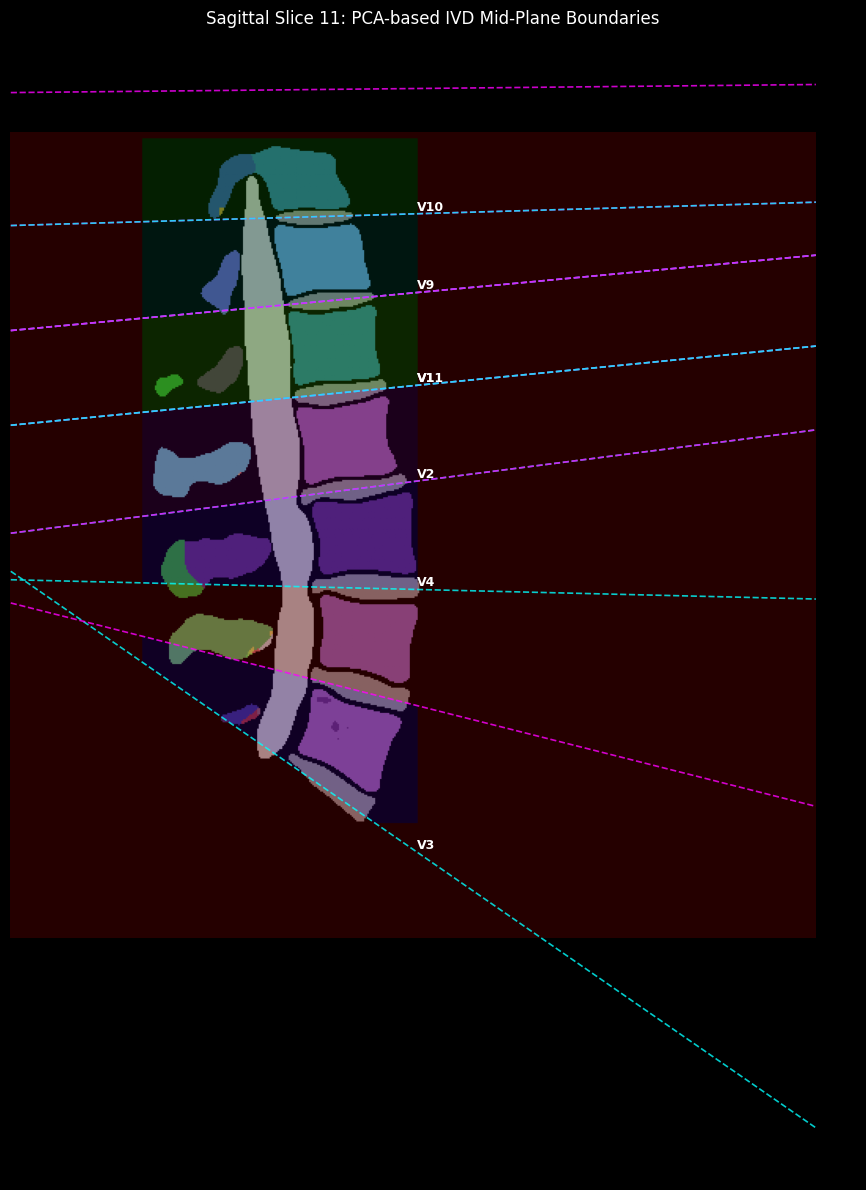

In [5]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label, binary_erosion, binary_dilation, generate_binary_structure, center_of_mass
from skimage.measure import regionprops
from skimage.segmentation import watershed
from scipy.spatial import cKDTree

def instance_aware_smart_voting(input_path, output_path, z_axis=0, erosion_iters=2, absolute_contact_thresh=20):
    print(f"Loading: {input_path}")
    img = nib.load(input_path)
    data = img.get_fdata().astype(np.uint16)
    
    bone_mask = (data == 1) | (data == 2)
    struct = generate_binary_structure(3, 1)
    
    # 1. Apply Erosion to break connections
    eroded_bone = binary_erosion(bone_mask, structure=struct, iterations=erosion_iters)
    labeled_cores, num_features = label(eroded_bone, structure=struct)
    
    if num_features == 0: 
        print("No bones found.")
        return

    print(f"Found {num_features} fragmented cores after erosion.")

    print("Extracting Spinal Canal Centerline...")
    canal_mask = (data == 4)

    # Get all unique Z-slices where the canal exists
    # Assuming z_axis=0 for the array dimensions (Z, Y, X)
    z_indices = np.unique(np.argwhere(canal_mask)[:, z_axis])

    centerline_pts = []
    for z in z_indices:
        slice_mask = canal_mask[:, :, z]
        if np.any(slice_mask):
            # Find 2D centroid of the canal in this slice
            x, y = center_of_mass(slice_mask)
            centerline_pts.append([x, y, z])

    # Convert to a NumPy array for fast vectorized distance calculations
    centerline_pts = np.array(centerline_pts)
    # print("centerline points: ")
    # print(centerline_pts)

    print("Extracting Intervertebral Discs (IVDs)...")
    ivd_mask = (data == 3)

    # Label the individual discs
    struct_join = generate_binary_structure(3, 2) 
    labeled_ivds, num_ivds = label(ivd_mask, structure=struct_join)

    ivd_centroids = []
    if num_ivds > 0:
        ivd_props = regionprops(labeled_ivds)

        # Store as a NumPy array for fast vectorized distance math
        ivd_centroids = np.array([p.centroid for p in ivd_props])
        ivd_data = {p.label: np.array(p.centroid) for p in ivd_props}

    # 2. WATERSHED: Expand the cores to fill the original bone mask boundaries
    # This ensures the 1-2 pixel gap is filled and fragments directly touch
    full_labeled_bones = watershed(np.zeros_like(data), labeled_cores, mask=bone_mask)

    # 3. Extract Properties
    props = regionprops(full_labeled_bones)
    volumes = {p.label: p.area for p in props}
    z_ranges = {p.label: (p.bbox[z_axis], p.bbox[z_axis + 3]) for p in props} 
    centroids = {p.label: p.centroid for p in props}

    # print(z_ranges)

    sorted_vols = sorted(list(volumes.values()), reverse=True)
    if len(sorted_vols) > 0:
        expected_size = np.median(sorted_vols[:min(7, len(sorted_vols))])
    else:
        expected_size = 1000 # Fallback if nothing is found

    print(sorted_vols)
    print(expected_size)

    canal_tree = cKDTree(centerline_pts)

    print("Calculating 3D territory and boundaries using Canal Centerline anchors...")
    
    # 4. Build Contact Graph (Now checking the fully expanded touching labels)
    edges = [] 
    for i in range(1, num_features + 1):
        mask_i = (full_labeled_bones == i)
        # Just 1 pixel dilation is needed now because the regions are directly touching
        dilated_i = binary_dilation(mask_i, structure=struct, iterations=1)
        neighbors_mask = dilated_i & bone_mask & ~mask_i 
        
        neighbor_labels = np.unique(full_labeled_bones[neighbors_mask])
        for n_label in neighbor_labels[neighbor_labels > 0]:
            if n_label > i:
                contact_area = np.sum(full_labeled_bones[neighbors_mask] == n_label)
                min_volume = min(volumes[i], volumes[n_label])
                overlap_ratio = contact_area / min_volume

                # Extract the vertical (Z) boundaries of both fragments
                z_min_i, z_max_i = z_ranges[i]
                z_min_j, z_max_j = z_ranges[n_label]
                
                # Calculate how many Z-slices they share
                overlap_start = max(z_min_i, z_min_j)
                overlap_end = min(z_max_i, z_max_j)
                z_overlap_pixels = max(0, overlap_end - overlap_start)
                
                # What percentage of fragment i's total height is covered by j?
                height_i = max(1, z_max_i - z_min_i)
                z_overlap_fraction = z_overlap_pixels / height_i
                
                # Create the final Merge Score: 
                # If they share vertical space, score stays high. 
                # If they only touch at the very tip (low Z-overlap), score gets crushed.
                merge_score = contact_area * (0.1 + z_overlap_fraction)

                edges.append((merge_score, overlap_ratio, contact_area, i, n_label))

    edges.sort(reverse=True, key=lambda x: x[0])

    # 5. Greedy Merging
    parent = {i: i for i in range(1, num_features + 1)}
    def find(i):
        if parent[i] == i: return i
        parent[i] = find(parent[i])
        return parent[i]

    for _, overlap_ratio, contact_area, a, b in edges:
        root_a = find(a)
        root_b = find(b)
        
        if root_a != root_b:
            # Z-Overlap check
            z_min_a, z_max_a = z_ranges[root_a]
            z_min_b, z_max_b = z_ranges[root_b]
            overlap_z = max(0, min(z_max_a, z_max_b) - max(z_min_a, z_min_b))
            
            if overlap_ratio > 0.25 or contact_area > 800 or (max(volumes[a], volumes[b]) < 800 and overlap_ratio > 0.1):
                parent[root_b] = root_a
                volumes[root_a] += volumes[root_b]
                z_ranges[root_a] = (min(z_min_a, z_min_b), max(z_max_a, z_max_b))

        # if root_a != root_b:
        #     # Z-Overlap check
        #     z_min_a, z_max_a = z_ranges[root_a]
        #     z_min_b, z_max_b = z_ranges[root_b]
        #     overlap_z = max(0, min(z_max_a, z_max_b) - max(z_min_a, z_min_b))
        #     ratio = (z_max_a - z_min_a)/(z_max_b - z_min_b)
        #     overlap_z_ratio = min(ratio, 1/ratio)
        #     vol_a = volumes[root_a]
        #     vol_b = volumes[root_b]
        #     # --- NEW ORPHAN ADOPTION LOGIC ---
        #     # Is one of the pieces unusually small? (e.g., a posterior element)
        #     is_orphan = min(vol_a, vol_b) < (expected_size * 0.25)
            
        #     # MERGE IF:
        #     # 1. Normal fragments with good Z-overlap and good contact area
        #     # OR
        #     # 2. It is an orphan fragment, it shares Z-space, and it has ANY contact (> 0)
        #     if overlap_z_ratio > 0.2:
        #         if contact_area > absolute_contact_thresh or (is_orphan and contact_area > 0):
        #             total_vol = volumes[root_a] + volumes[root_b]
        #             if total_vol < expected_size*(1.3):
        #                 parent[root_b] = root_a
        #                 volumes[root_a] += volumes[root_b]
        #                 z_ranges[root_a] = (min(z_min_a, z_min_b), max(z_max_a, z_max_b))

    # 6. Phase 3: Smart Orphan Rescue
    all_roots = set(find(i) for i in range(1, num_features + 1) if volumes[i] > 0)
    
    # CRITICAL FIX: The top-tier root is ALWAYS a main body, even if tiny
    main_bodies = [r for r in all_roots if volumes[r] >= (0.3 * expected_size)]
    # Orphans are small things that are NOT the top-tier
    orphans = [r for r in all_roots if volumes[r] < (0.3 * expected_size)]
    
    print(f"Phase 3: Found {len(main_bodies)} Main bodies and Rescuing {len(orphans)} orphans. (Protected Top-Tier from being rescued)")
    orphans_rescued = 0

    for orphan in orphans:
        if not main_bodies: break
        
        orphan_centroid = np.array(centroids[orphan])
        o_z_min, o_z_max = z_ranges[orphan]
        
        best_match = None
        best_score = float('inf')

        print(f"case : {orphan}")
        
        for mb in main_bodies:

            print(f"    finding score for {mb}")
                
            mb_centroid = np.array(centroids[mb])
            dist = np.linalg.norm(orphan_centroid - mb_centroid)
            
            # THE STRIPE FIX: Check Z-alignment
            mb_z_min, mb_z_max = z_ranges[mb]
            
            # Does this orphan exist within the vertical span of this main body?
            is_contained_z = (o_z_min >= mb_z_min - 2) and (o_z_max <= mb_z_max + 2)

            # Calculate how many Z-slices they share
            # overlap_start = max(o_z_min, mb_z_min)
            # overlap_end = min(o_z_max, mb_z_max)
            # z_overlap_pixels = max(0, overlap_end - overlap_start)
            
            # # What percentage of fragment i's total height is covered by j?
            # height_i = max(1, o_z_max - o_z_min)
            # z_overlap_fraction = z_overlap_pixels / height_i

            # score = dist - (z_overlap_fraction)*20

            # --- Inside your merging loop for main body (mb) and orphan (o) ---
            mb_c = np.array(centroids[mb]) # Assumed format: (Z, Y, X)
            z_idx = z_axis # Assuming Z is the first axis in your volume

            # # 1. FIND THE UPPER AND LOWER DISCS
            # # Split all disc centroids into those physically above and below the mb's Z-level
            # ivds_above = ivd_centroids[ivd_centroids[:, z_idx] < mb_c[z_idx]]
            # ivds_below = ivd_centroids[ivd_centroids[:, z_idx] > mb_c[z_idx]]

            # # Initialize fallbacks in case a vertebra is at the very edge of the scan
            # local_axis = np.array([1.0, 0.0, 0.0]) # Default straight Z
            # b_upper, b_lower = mb_c[z_idx] - 15, mb_c[z_idx] + 15 

            # if len(ivds_above) > 0 and len(ivds_below) > 0:
            #     # Find the single closest disc centroid from the 'above' group and 'below' group
            #     c_upper = ivds_above[np.argmin(np.linalg.norm(ivds_above - mb_c, axis=1))]
            #     c_lower = ivds_below[np.argmin(np.linalg.norm(ivds_below - mb_c, axis=1))]
                
            #     # 2. DEFINE THE LOCAL SPINE AXIS
            #     vector_spine = c_lower - c_upper
            #     norm = np.linalg.norm(vector_spine)
            #     if norm > 0:
            #         local_axis = vector_spine / norm # Normalize to unit vector
                    
            #     # The boundaries of our "territory slab" are the projected 1D positions of the discs
            #     b_upper = np.dot(c_upper, local_axis)
            #     b_lower = np.dot(c_lower, local_axis)
                
            # elif len(ivds_above) > 0: 
            #     # Edge case: Lowest vertebra (missing bottom disc)
            #     c_upper = ivds_above[np.argmin(np.linalg.norm(ivds_above - mb_c, axis=1))]
            #     b_upper = np.dot(c_upper, local_axis)
            #     dist_to_c = np.linalg.norm(c_upper - mb_c)
            #     b_lower = b_upper + (dist_to_c * 2) # Estimate bottom boundary
                
            # elif len(ivds_below) > 0: 
            #     # Edge case: Highest vertebra (missing top disc)
            #     c_lower = ivds_below[np.argmin(np.linalg.norm(ivds_below - mb_c, axis=1))]
            #     b_lower = np.dot(c_lower, local_axis)
            #     dist_to_c = np.linalg.norm(c_lower - mb_c)
            #     b_upper = b_lower - (dist_to_c * 2) # Estimate top boundary

            # 1. FIND THE CORRECT UPPER AND LOWER DISCS
            # We still use mb_c just to identify WHICH disc is above/below
            above_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_idx] < mb_c[z_idx]}
            below_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_idx] > mb_c[z_idx]}

            local_axis = np.array([0.0, 0.0, 1.0]) # Default straight Z
            b_upper, b_lower = mb_c[z_idx] - 15, mb_c[z_idx] + 15 

            c_upper, c_lower = None, None

            if above_candidates:
                # Find the label of the nearest disc above
                upper_lbl = min(above_candidates, key=lambda k: np.linalg.norm(above_candidates[k] - mb_c))
                upper_coords = np.argwhere(labeled_ivds == upper_lbl)
                
                # THE CANAL FIX: Query the KDTree. 
                # 'distances' is the distance from each disc voxel to the nearest canal point.
                distances, _ = canal_tree.query(upper_coords)
                
                # The anchor point is the disc voxel with the smallest distance to the canal
                c_upper = upper_coords[np.argmin(distances)]
                b_upper = np.dot(c_upper, local_axis) 

            if below_candidates:
                # Find the label of the nearest disc below
                lower_lbl = min(below_candidates, key=lambda k: np.linalg.norm(below_candidates[k] - mb_c))
                lower_coords = np.argwhere(labeled_ivds == lower_lbl)
                
                # THE CANAL FIX: Find closest voxel to the spinal canal
                distances, _ = canal_tree.query(lower_coords)
                
                # The anchor point is the disc voxel with the smallest distance to the canal
                c_lower = lower_coords[np.argmin(distances)]
                b_lower = np.dot(c_lower, local_axis) 

            # 2. DEFINE THE LOCAL SPINE AXIS USING THE CANAL ANCHORS
            if c_upper is not None and c_lower is not None:
                vector_spine = c_lower - c_upper
                norm = np.linalg.norm(vector_spine)
                if norm > 0:
                    local_axis = vector_spine / norm
                    
                b_upper = np.dot(c_upper, local_axis)
                b_lower = np.dot(c_lower, local_axis)

            # 3. GET ORPHAN COORDINATES AND PROJECT THEM
            o_coords = np.argwhere(full_labeled_bones == orphan)

            # Project all 3D orphan voxels onto our 1D local spinal axis
            o_proj = np.dot(o_coords, local_axis)

            # Ensure min/max ordering is correct regardless of vector direction
            slab_min = min(b_upper, b_lower)
            slab_max = max(b_upper, b_lower)

            print(f"slab min/max: {slab_min} / {slab_max}")

            # 4. CALCULATE VOLUME OVERLAP
            # Count how many orphan voxels fall strictly between the upper and lower bounding planes
            voxels_inside_slab = np.sum((o_proj >= slab_min) & (o_proj <= slab_max))
            total_orphan_voxels = len(o_coords)

            if total_orphan_voxels > 0:
                # What fraction of the orphan's volume is inside this main body's territory?
                z_overlap_fraction = voxels_inside_slab / total_orphan_voxels
            else:
                z_overlap_fraction = 0.0

            # Calculate final score based on distance and overlap inside the "pentagon" territory
            # score = dist - (z_overlap_fraction * 20)

            if z_overlap_fraction > 0:
                # Base score reduction: The higher the overlap, the closer the score gets to 0.
                score = dist * (1.0 - z_overlap_fraction)
                
                # The "Guarantee" Multiplier:
                # If a significant chunk (>40%) is inside the slab, it almost certainly belongs there.
                # We multiply by 0.01 to crush the score and guarantee it wins against non-overlapping bones.
                if z_overlap_fraction >= 0.40:
                    score *= 0.01
            else:
                # If it has ZERO overlap with this slab, penalize the distance so it rarely wins.
                score = dist * 2.0

            print(f"    Score: {score}, dist: {dist}, z_overlap_fraction: {z_overlap_fraction}, is contained z: {is_contained_z}")

            # if is_contained_z:
            #     score *= 0.5  # Huge priority boost for vertically aligned stripes

            # if z_overlap_fraction >= 0.60: 
            #     score *= 0.5
            
            if score < best_score:
                best_score = score
                best_match = mb

        if best_match is not None:
            print(f"    best match {best_match}, with score {best_score}")
            parent[orphan] = best_match
            volumes[best_match] += volumes[orphan]
            orphans_rescued += 1

    print(f"Orphans Force-Rescued : {orphans_rescued}")

    # 6. Paint Final Mask
    final_output = np.copy(data)
    final_output[bone_mask] = 0 

    merged_groups = {}
    for i in range(1, num_features + 1):
        root = find(i)
        merged_groups.setdefault(root, []).append(i)

    print(f"Reduced to {len(merged_groups)} consolidated Vertebrae.")

    sorted_roots = sorted(merged_groups.keys(), key=lambda r: z_ranges[r][0])

    # 7. Apply Majority Voting per merged instance
    # for root, members in merged_groups.items():
    #     group_mask = np.isin(full_labeled_bones, members)
        
    #     raw_votes = data[group_mask]
    #     bone_votes = raw_votes[(raw_votes == 1) | (raw_votes == 2)]
        
    #     if len(bone_votes) > 0:
    #         winner = 1 if np.sum(bone_votes == 1) > np.sum(bone_votes == 2) else 2
    #         final_output[group_mask] = winner

    # 7. Apply Unique Instance IDs
    start_id = 201
    actual_instance_count = 0

    for i, root in enumerate(sorted_roots):
        members = merged_groups[root]
        group_mask = np.isin(full_labeled_bones, members)
        
        # Intelligent Filter: Only label it if it's large enough to be a vertebra
        # (Avoids giving an ID to a tiny speck of noise)
        if volumes[root] > (expected_size * 0.001):
            current_instance_id = start_id + actual_instance_count
            final_output[group_mask] = current_instance_id
            actual_instance_count += 1
            
            # Optional: Print the "Legacy" majority for your records
            # raw_votes = data[group_mask]
            # legacy_class = "Odd" if np.sum(raw_votes==1) > np.sum(raw_votes==2) else "Even"
            # print(f"Instance {current_instance_id}: Size {volumes[root]} (Originally {legacy_class})")

    print(f"Successfully labeled {actual_instance_count} vertebrae with IDs {start_id} to {start_id + actual_instance_count - 1}")

    new_img = nib.Nifti1Image(final_output.astype(np.uint16), img.affine, img.header)
    nib.save(new_img, output_path)
    print(f"Success. Saved to {output_path}")

    visualize_spinal_territories(input_path, full_labeled_bones, main_bodies, output_png_path='slab_viz_case_50.png')

# Example Usage:
# INPUT_MASK = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_191.nii.gz"
# OUTPUT_MASK = "predictions_real_test/prediction_mj_voting_191.nii.gz" 
# instance_aware_smart_voting(INPUT_MASK, OUTPUT_MASK, z_axis=0, erosion_iters=1, absolute_contact_thresh=50)

# Example execution:
# erosion_based_smart_voting('input.nii.gz', 'output_fixed.nii.gz', z_axis=0, erosion_iters=1)

# Example Usage:
INPUT_MASK = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_201.nii.gz"      
OUTPUT_MASK = "predictions_real_test/prediction_mj_voting_201.nii.gz" 
# INPUT_MASK = "predictions_real_test/prediction_core_fixed_191.nii.gz"
instance_aware_smart_voting(INPUT_MASK, OUTPUT_MASK, z_axis=2, erosion_iters=1)

Loading: predictions_real_test/prediction_core_fixed_201.nii.gz
Found 46 fragmented cores after erosion.
Extracting Spinal Canal Centerline...
Extracting Intervertebral Discs (IVDs)...
Dynamic size detected: Cliff at index 0 (Drop: 2.20x). Expected Size: 91096.0
[91096.0, 41376.0, 34714.0, 26820.0, 22848.0, 14606.0, 8457.0, 7582.0, 5044.0, 4777.0, 4524.0, 4450.0, 2790.0, 1395.0, 1269.0, 1245.0, 1142.0, 702.0, 676.0, 673.0, 536.0, 219.0, 162.0, 114.0, 103.0, 82.0, 71.0, 67.0, 58.0, 44.0, 21.0, 21.0, 18.0, 16.0, 14.0, 11.0, 11.0, 10.0, 9.0, 6.0, 6.0, 6.0, 5.0, 5.0, 5.0, 4.0]
22000
Calculating 3D territory and boundaries using Canal Centerline anchors...
Phase 3: Found 8 Main bodies and Rescuing 38 orphans.
Floaters rescued: 0
Reduced to 46 consolidated Vertebrae.
Successfully labeled 30 vertebrae with IDs 201 to 230
Success. Saved to predictions_real_test/prediction_mj_voting_201.nii.gz
Loading MRI for visualization: predictions_real_test/prediction_core_fixed_201.nii.gz
Calculating PCA-

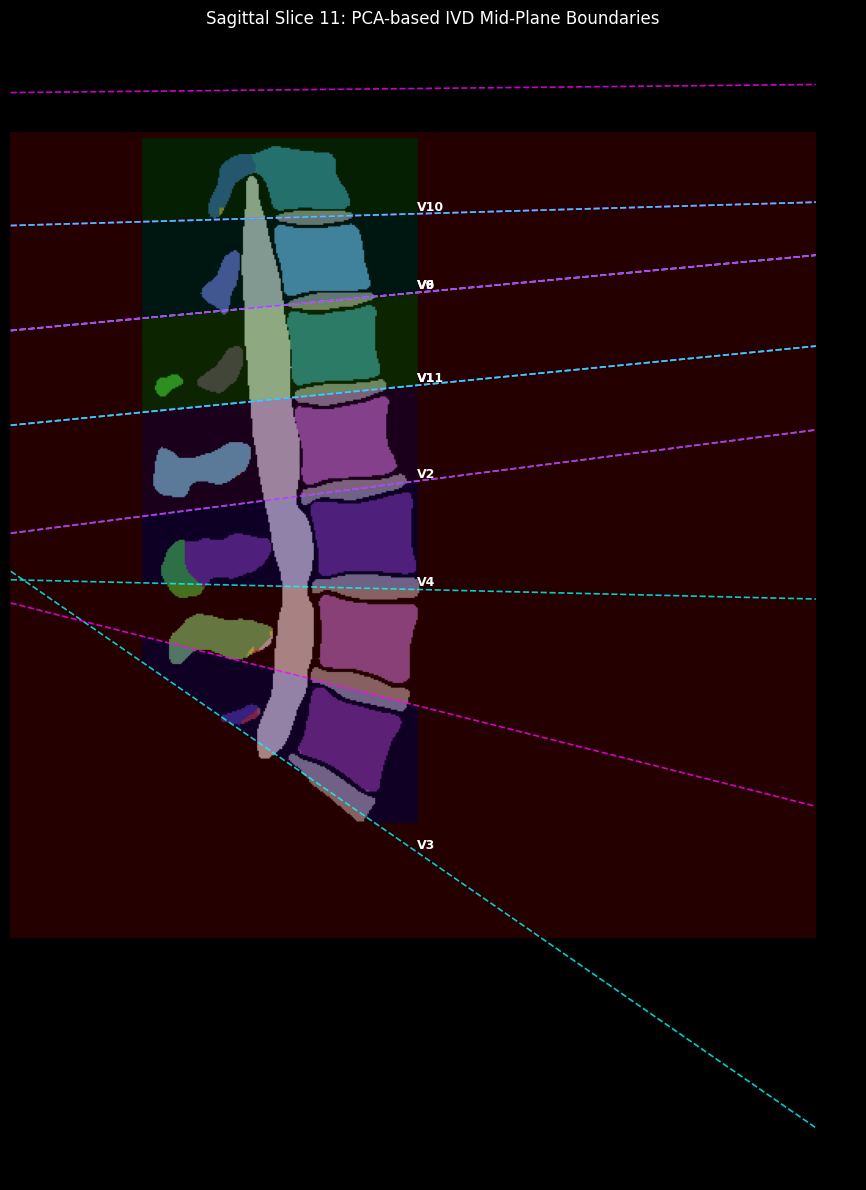

In [ ]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label, binary_erosion, binary_dilation, generate_binary_structure, center_of_mass
from skimage.measure import regionprops
from skimage.segmentation import watershed
from scipy.spatial import cKDTree

def instance_aware_smart_voting(input_path, output_path, z_axis=0, erosion_iters=2, absolute_contact_thresh=20):
    print(f"Loading: {input_path}")
    img = nib.load(input_path)
    data = img.get_fdata().astype(np.uint16)
    
    bone_mask = (data == 1) | (data == 2)
    struct = generate_binary_structure(3, 1)
    
    # 1. Apply Erosion to break connections
    eroded_bone = binary_erosion(bone_mask, structure=struct, iterations=erosion_iters)
    labeled_cores, num_features = label(eroded_bone, structure=struct)
    
    if num_features == 0: 
        print("No bones found.")
        return

    print(f"Found {num_features} fragmented cores after erosion.")

    print("Extracting Spinal Canal Centerline...")
    canal_mask = (data == 4)

    # Get all unique Z-slices where the canal exists
    # Assuming z_axis=0 for the array dimensions (Z, Y, X)
    z_indices = np.unique(np.argwhere(canal_mask)[:, z_axis])

    centerline_pts = []
    for z in z_indices:
        slice_mask = canal_mask[:, :, z]
        if np.any(slice_mask):
            # Find 2D centroid of the canal in this slice
            x, y = center_of_mass(slice_mask)
            centerline_pts.append([x, y, z])

    # Convert to a NumPy array for fast vectorized distance calculations
    centerline_pts = np.array(centerline_pts)
    # print("centerline points: ")
    # print(centerline_pts)

    print("Extracting Intervertebral Discs (IVDs)...")
    ivd_mask = (data == 3)

    # Label the individual discs
    struct_join = generate_binary_structure(3, 2) 
    labeled_ivds, num_ivds = label(ivd_mask, structure=struct_join)

    ivd_centroids = []
    if num_ivds > 0:
        ivd_props = regionprops(labeled_ivds)

        # Store as a NumPy array for fast vectorized distance math
        ivd_centroids = np.array([p.centroid for p in ivd_props])
        ivd_data = {p.label: np.array(p.centroid) for p in ivd_props}

    thick_discs = binary_dilation(ivd_mask, structure=struct, iterations=1)
    severed_bone_mask = bone_mask & ~thick_discs

    eroded_bone = binary_erosion(severed_bone_mask, structure=struct, iterations=erosion_iters)
    labeled_cores, num_features = label(eroded_bone, structure=struct)

    # 2. WATERSHED: Expand the cores to fill the original bone mask boundaries
    # This ensures the 1-2 pixel gap is filled and fragments directly touch
    full_labeled_bones = watershed(np.zeros_like(data), labeled_cores, mask=bone_mask)

    # 3. Extract Properties
    props = regionprops(full_labeled_bones)
    volumes = {p.label: p.area for p in props}
    z_ranges = {p.label: (p.bbox[z_axis], p.bbox[z_axis + 3]) for p in props} 
    centroids = {p.label: p.centroid for p in props}

    # print(z_ranges)

    sorted_vols = sorted(list(volumes.values()), reverse=True)
    
    if len(sorted_vols) > 0:
        # Search for a volume "cliff" in the top 15 elements
        search_range = min(15, len(sorted_vols))
        best_cliff_idx = 0
        max_drop = 0
        
        for i in range(search_range - 1):
            # Ratio of current volume to the next volume
            drop = sorted_vols[i] / (sorted_vols[i+1] + 1e-5)
            
            # We want the biggest drop. 
            # The "i > 0 or drop < 3.0" rule prevents a single massive 
            # watershed leak/outlier at index 0 from hijacking the logic.
            if drop > max_drop and (i > 0 or drop < 3.0): 
                max_drop = drop
                best_cliff_idx = i
                
        # Fallback if the drop is very gradual (no clear cliff)
        if max_drop < 1.5:
            best_cliff_idx = min(6, len(sorted_vols) - 1)
            
        # The true main bodies are everything before and including the cliff
        main_bodies = sorted_vols[:best_cliff_idx + 1]
        
        # Take the median of ONLY the true main bodies
        expected_size = np.median(main_bodies)
        print(f"Dynamic size detected: Cliff at index {best_cliff_idx} (Drop: {max_drop:.2f}x). Expected Size: {expected_size}")
    else:
        expected_size = 1000 # Fallback if nothing is found
    expected_size = 22000
    print(sorted_vols)
    print(expected_size)

    # canal_tree = cKDTree(centerline_pts)

    print("Calculating 3D territory and boundaries using Canal Centerline anchors...")
    
    # 4. Build Contact Graph (Now checking the fully expanded touching labels)
    edges = [] 
    for i in range(1, num_features + 1):
        mask_i = (full_labeled_bones == i)
        # Just 1 pixel dilation is needed now because the regions are directly touching
        dilated_i = binary_dilation(mask_i, structure=struct, iterations=1)
        neighbors_mask = dilated_i & bone_mask & ~mask_i 
        
        neighbor_labels = np.unique(full_labeled_bones[neighbors_mask])
        for n_label in neighbor_labels[neighbor_labels > 0]:
            if n_label > i:
                contact_area = np.sum(full_labeled_bones[neighbors_mask] == n_label)
                min_volume = min(volumes[i], volumes[n_label])
                overlap_ratio = min(1.0, contact_area / min_volume)

                # Extract the vertical (Z) boundaries of both fragments
                z_min_i, z_max_i = z_ranges[i]
                z_min_j, z_max_j = z_ranges[n_label]
                
                # Calculate how many Z-slices they share
                overlap_start = max(z_min_i, z_min_j)
                overlap_end = min(z_max_i, z_max_j)
                z_overlap_pixels = max(0, overlap_end - overlap_start)
                
                # What percentage of fragment i's total height is covered by j?
                height_i = max(1, z_max_i - z_min_i)
                z_overlap_fraction = z_overlap_pixels / height_i
                
                # Create the final Merge Score: 
                # If they share vertical space, score stays high. 
                # If they only touch at the very tip (low Z-overlap), score gets crushed.
                merge_score = contact_area * (0.1 + z_overlap_fraction)

                edges.append((merge_score, overlap_ratio, contact_area, i, n_label))

    edges.sort(reverse=True, key=lambda x: x[0])

    # 5. Greedy Merging
    parent = {i: i for i in range(1, num_features + 1)}
    def find(i):
        if parent[i] == i: return i
        parent[i] = find(parent[i])
        return parent[i]
    
    def get_ivd_plane(coords):

        """
        Runs PCA on the 3D coordinates of an IVD to find its flattest mid-plane.
        Returns the centroid (point on the plane) and the normal vector.
        """

        if len(coords) < 3:
            # Fallback if the mask is weirdly tiny
            return np.mean(coords, axis=0), np.array([0.0, 0.0, 1.0])

        centroid = np.mean(coords, axis=0)

        centered = coords - centroid

        cov = np.cov(centered.T)

        # Calculate eigenvalues and eigenvectors

        eigenvalues, eigenvectors = np.linalg.eigh(cov)
       
        # The normal vector to the flattest plane corresponds to the smallest eigenvalue

        # eigh returns them in ascending order, so index 0 is the smallest.

        normal = eigenvectors[:, 0]

        return centroid, normal

    # for _, overlap_ratio, contact_area, a, b in edges:

    #     root_a = find(a)
    #     root_b = find(b)

    #     vol_a = volumes[root_a]
    #     vol_b = volumes[root_b]

    #     if root_a != root_b:
    #         # Z-Overlap check
    #         z_min_a, z_max_a = z_ranges[root_a]
    #         z_min_b, z_max_b = z_ranges[root_b]
    #         overlap_z = max(0, min(z_max_a, z_max_b) - max(z_min_a, z_min_b))

    #         if min(vol_a, vol_b) > (0.4 * expected_size) and overlap_ratio < 0.75:
    #             continue

    #         if (min(volumes[a], volumes[b]) > 100 and overlap_ratio > 0.25) or contact_area > 1000:
    #             print("Overlap ratio: ", overlap_ratio, ", z min/max: ", z_min_a, z_max_a, ", contact area: ", contact_area, ", volumes a/b: ", volumes[a], volumes[b])
    #             parent[root_b] = root_a
    #             volumes[root_a] += volumes[root_b]
    #             z_ranges[root_a] = (min(z_min_a, z_min_b), max(z_max_a, z_max_b))

    # ---------------------------------------------------------
    # PRE-COMPUTE: 3D IVD Mid-Planes (Do this OUTSIDE the loop)
    # ---------------------------------------------------------
    all_roots = set(find(i) for i in range(1, num_features + 1) if volumes[i] > 0)
    main_bodies = [r for r in all_roots if volumes[r] >= (0.3 * expected_size)]
    orphans = [r for r in all_roots if volumes[r] < (0.3 * expected_size)]
    main_bodies_set = set(main_bodies)
    orphans_set = set(orphans)
    
    print(f"Phase 3: Found {len(main_bodies)} Main bodies and Rescuing {len(orphans)} orphans.")

    mb_slabs = {}
    for mb in main_bodies:
        mb_c = np.array(centroids[mb])
        
        above_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_axis] < mb_c[z_axis]}
        below_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_axis] > mb_c[z_axis]}

        plane_upper = None
        plane_lower = None

        if above_candidates:
            upper_lbl = min(above_candidates, key=lambda k: np.linalg.norm(above_candidates[k] - mb_c))
            upper_coords = np.argwhere(labeled_ivds == upper_lbl)
            c_up, n_up = get_ivd_plane(upper_coords)
            mb_side_up = np.sign(np.dot(n_up, mb_c - c_up))
            if mb_side_up == 0: mb_side_up = 1
            plane_upper = (c_up, n_up, mb_side_up)

        if below_candidates:
            lower_lbl = min(below_candidates, key=lambda k: np.linalg.norm(below_candidates[k] - mb_c))
            lower_coords = np.argwhere(labeled_ivds == lower_lbl)
            c_low, n_low = get_ivd_plane(lower_coords)
            mb_side_low = np.sign(np.dot(n_low, mb_c - c_low))
            if mb_side_low == 0: mb_side_low = 1
            plane_lower = (c_low, n_low, mb_side_low)

        mb_slabs[mb] = {'upper': plane_upper, 'lower': plane_lower}

    # ---------------------------------------------------------
    # PHASE 3: Smart Orphan Rescue
    # ---------------------------------------------------------
    orphans_rescued = 0

    for orphan in orphans:
        if not main_bodies: break

        o_parent = find(orphan)

        if o_parent in main_bodies_set: continue
        
        orphan_centroid = np.array(centroids[orphan])
        o_z_min, o_z_max = z_ranges[orphan]
        o_z_center = (o_z_min + o_z_max) / 2.0
        
        o_coords = np.argwhere(full_labeled_bones == orphan)
        if len(o_coords) == 0: 
            continue # FIX: Use continue, not return!
        
        best_match = None
        best_score = float('-inf')

        for mb in main_bodies:
            mb_centroid = np.array(centroids[mb])
            mb_z_min, mb_z_max = z_ranges[mb]
            mb_z_center = (mb_z_min + mb_z_max) / 2.0
            
            dist = np.linalg.norm(orphan_centroid - mb_centroid)
            slab = mb_slabs[mb]
            
            # 1. Calculate 3D Slab Overlap
            if slab['upper'] is None and slab['lower'] is None:
                z_overlap_fraction = 0.5 
            else:
                valid_mask = np.ones(len(o_coords), dtype=bool)

                if slab['upper'] is not None:
                    c_up, n_up, mb_sign_up = slab['upper']
                    dots_up = np.dot(o_coords - c_up, n_up)
                    valid_mask &= ((np.sign(dots_up) == mb_sign_up) | (dots_up == 0))

                if slab['lower'] is not None:
                    c_low, n_low, mb_sign_low = slab['lower']
                    dots_low = np.dot(o_coords - c_low, n_low)
                    valid_mask &= ((np.sign(dots_low) == mb_sign_low) | (dots_low == 0))

                z_overlap_fraction = np.sum(valid_mask) / len(o_coords)

            # 2. Hybrid Scoring (Slab Overlap + Anatomical Alignment)
            score = z_overlap_fraction * 2.0 # Weight the slab overlap heavily
            
            # FIX: The Anti-Theft Penalty. 
            # Penalize the score based on how far the vertical centers are.
            # This stops the lower vertebra from stealing a drooping tail!
            z_center_dist = abs(o_z_center - mb_z_center)
            score -= (z_center_dist * 0.05) 
            
            score -= (dist * 0.0001) # Micro penalty for general 3D distance
            
            if z_overlap_fraction < 0.15:
                score -= 10.0 # Heavy penalty if completely outside the 3D territory

            if score > best_score:
                best_score = score
                best_match = mb

        # Assign if mathematically viable
        if best_match is not None:
            parent[orphan] = best_match
            volumes[best_match] += volumes[orphan]
            
            # Update the bounding box of the main body to include the new orphan
            mb_z_min, mb_z_max = z_ranges[best_match]
            z_ranges[best_match] = (min(mb_z_min, o_z_min), max(mb_z_max, o_z_max))
            
            orphans_rescued += 1

    print(f"Floaters rescued: {orphans_rescued}")

    # 6. Paint Final Mask
    final_output = np.copy(data)
    final_output[bone_mask] = 0 

    merged_groups = {}
    for i in range(1, num_features + 1):
        root = find(i)
        merged_groups.setdefault(root, []).append(i)

    print(f"Reduced to {len(merged_groups)} consolidated Vertebrae.")

    sorted_roots = sorted(merged_groups.keys(), key=lambda r: z_ranges[r][0])

    # 7. Apply Unique Instance IDs
    start_id = 201
    actual_instance_count = 0

    for i, root in enumerate(sorted_roots):
        members = merged_groups[root]
        group_mask = np.isin(full_labeled_bones, members)
        
        # Intelligent Filter: Only label it if it's large enough to be a vertebra
        # (Avoids giving an ID to a tiny speck of noise)
        if volumes[root] > (expected_size * 0.001):
            current_instance_id = start_id + actual_instance_count
            final_output[group_mask] = current_instance_id
            actual_instance_count += 1
            
            # Optional: Print the "Legacy" majority for your records
            # raw_votes = data[group_mask]
            # legacy_class = "Odd" if np.sum(raw_votes==1) > np.sum(raw_votes==2) else "Even"
            # print(f"Instance {current_instance_id}: Size {volumes[root]} (Originally {legacy_class})")

    print(f"Successfully labeled {actual_instance_count} vertebrae with IDs {start_id} to {start_id + actual_instance_count - 1}")

    new_img = nib.Nifti1Image(final_output.astype(np.uint16), img.affine, img.header)
    nib.save(new_img, output_path)
    print(f"Success. Saved to {output_path}")

    visualize_spinal_territories(input_path, full_labeled_bones, main_bodies, output_png_path='slab_viz_case_50.png')

# Example Usage:
# INPUT_MASK = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_191.nii.gz"
# OUTPUT_MASK = "predictions_real_test/prediction_mj_voting_191.nii.gz" 
# instance_aware_smart_voting(INPUT_MASK, OUTPUT_MASK, z_axis=0, erosion_iters=1, absolute_contact_thresh=50)

# Example execution:
# erosion_based_smart_voting('input.nii.gz', 'output_fixed.nii.gz', z_axis=0, erosion_iters=1)

# Example Usage:
INPUT_MASK = "predictions_real_test/prediction_core_fixed_201.nii.gz"      
OUTPUT_MASK = "predictions_real_test/prediction_mj_voting_201.nii.gz" 
# INPUT_MASK = "predictions_real_test/prediction_core_fixed_191.nii.gz"
instance_aware_smart_voting(INPUT_MASK, OUTPUT_MASK, z_axis=2, erosion_iters=1)

### Updated algorithm with contac_area

In [17]:
import numpy as np
import nibabel as nib
from scipy.ndimage import binary_erosion, binary_dilation, generate_binary_structure, label, center_of_mass
from skimage.measure import regionprops
from skimage.segmentation import watershed
from scipy.spatial import cKDTree

def instance_aware_smart_voting(input_path, output_path, z_axis=0, erosion_iters=2, absolute_contact_thresh=20):
    print(f"Loading: {input_path}")
    img = nib.load(input_path)
    data = img.get_fdata().astype(np.uint16)
    
    bone_mask = (data == 1) | (data == 2)
    struct = generate_binary_structure(3, 1)
    
    # 1. Apply Erosion to break connections
    eroded_bone = binary_erosion(bone_mask, structure=struct, iterations=erosion_iters)
    labeled_cores, num_features = label(eroded_bone, structure=struct)
    
    if num_features == 0: 
        print("No bones found.")
        return

    print(f"Found {num_features} fragmented cores after erosion.")

    print("Extracting Spinal Canal Centerline...")
    canal_mask = (data == 4)

    # Get all unique Z-slices where the canal exists
    z_indices = np.unique(np.argwhere(canal_mask)[:, z_axis])

    centerline_pts = []
    for z in z_indices:
        slice_mask = canal_mask[:, :, z]
        if np.any(slice_mask):
            # BUG FIX 1: center_of_mass returns (X, Y) matching array dimensions
            cx, cy = center_of_mass(slice_mask)
            centerline_pts.append([cx, cy, z])

    centerline_pts = np.array(centerline_pts)
    canal_tree = cKDTree(centerline_pts)

    print("Extracting Intervertebral Discs (IVDs)...")
    ivd_mask = (data == 3)
    struct_join = generate_binary_structure(3, 2) 
    labeled_ivds, num_ivds = label(ivd_mask, structure=struct_join)

    ivd_centroids = []
    ivd_data = {}
    if num_ivds > 0:
        ivd_props = regionprops(labeled_ivds)
        ivd_centroids = np.array([p.centroid for p in ivd_props])
        ivd_data = {p.label: np.array(p.centroid) for p in ivd_props}

    # 2. WATERSHED: Expand the cores to fill the original bone mask boundaries
    full_labeled_bones = watershed(np.zeros_like(data), labeled_cores, mask=bone_mask)

    # 3. Extract Properties
    props = regionprops(full_labeled_bones)
    volumes = {p.label: p.area for p in props}
    z_ranges = {p.label: (p.bbox[z_axis], p.bbox[z_axis + 3]) for p in props} 
    centroids = {p.label: p.centroid for p in props}
    
    # Cache coords for fast volume math later
    coords_dict = {p.label: p.coords for p in props}

    sorted_vols = sorted(list(volumes.values()), reverse=True)
    if len(sorted_vols) > 0:
        expected_size = np.median(sorted_vols[:min(7, len(sorted_vols))])
    else:
        expected_size = 1000

    # Phase 1 Setup: Define Main Bodies vs Orphans
    main_bodies = [lbl for lbl, vol in volumes.items() if vol >= (0.3 * expected_size)]
    orphans = [lbl for lbl, vol in volumes.items() if vol < (0.3 * expected_size)]
    
    print(f"Phase 1: Identified {len(main_bodies)} Main Bodies and {len(orphans)} Orphans.")
    print("Pre-computing 3D Territorial Slabs for Main Bodies...")

    mb_slabs = {}
    for mb in main_bodies:
        mb_c = np.array(centroids[mb])
        z_idx = z_axis
        
        above_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_idx] < mb_c[z_idx]}
        below_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_idx] > mb_c[z_idx]}

        local_axis = np.array([0.0, 0.0, 1.0]) 
        b_upper, b_lower = mb_c[z_idx] - 15, mb_c[z_idx] + 15 
        c_upper, c_lower = None, None

        if above_candidates:
            upper_lbl = min(above_candidates, key=lambda k: np.linalg.norm(above_candidates[k] - mb_c))
            upper_coords = np.argwhere(labeled_ivds == upper_lbl)
            distances, _ = canal_tree.query(upper_coords)
            c_upper = upper_coords[np.argmin(distances)]
            b_upper = np.dot(c_upper, local_axis) 

        if below_candidates:
            lower_lbl = min(below_candidates, key=lambda k: np.linalg.norm(below_candidates[k] - mb_c))
            lower_coords = np.argwhere(labeled_ivds == lower_lbl)
            distances, _ = canal_tree.query(lower_coords)
            c_lower = lower_coords[np.argmin(distances)]
            b_lower = np.dot(c_lower, local_axis) 

        if c_upper is not None and c_lower is not None:
            vector_spine = c_lower - c_upper
            norm = np.linalg.norm(vector_spine)
            if norm > 0:
                local_axis = vector_spine / norm
            b_upper = np.dot(c_upper, local_axis)
            b_lower = np.dot(c_lower, local_axis)

        mb_slabs[mb] = {
            'local_axis': local_axis,
            'slab_min': min(b_upper, b_lower),
            'slab_max': max(b_upper, b_lower)
        }

    # Helper function for Z-Overlap
    def get_z_overlap(orphan_lbl, mb_lbl):
        o_coords = coords_dict[orphan_lbl]
        if len(o_coords) == 0: return 0.0
        
        slab = mb_slabs[mb_lbl]
        o_proj = np.dot(o_coords, slab['local_axis'])
        voxels_inside = np.sum((o_proj >= slab['slab_min']) & (o_proj <= slab['slab_max']))
        return voxels_inside / len(o_coords)

    # 4. Build Pure Contact Graph
    print("Extracting physical boundaries...")
    contact_edges = []
    for i in range(1, num_features + 1):
        mask_i = (full_labeled_bones == i)
        dilated_i = binary_dilation(mask_i, structure=struct, iterations=1)
        neighbors_mask = dilated_i & bone_mask & ~mask_i 
        
        neighbor_labels = np.unique(full_labeled_bones[neighbors_mask])
        for n_label in neighbor_labels[neighbor_labels > i]: # > i prevents duplicate pairs
            contact_area = np.sum(full_labeled_bones[neighbors_mask] == n_label)
            contact_edges.append((contact_area, i, n_label))

    # DSU Setup
    parent = {i: i for i in range(1, num_features + 1)}
    def find(i):
        if parent[i] == i: return i
        parent[i] = find(parent[i])
        return parent[i]

    # Phase 2: Multi-Factor Iterative Growth (Chain Reaction)
    print("Phase 2: Executing Seeded Region Growing...")
    merges_made = True
    chain_reaction_loops = 0

    while merges_made:
        merges_made = False
        valid_merges = []
        chain_reaction_loops += 1

        for contact_area, a, b in contact_edges:
            root_a = find(a)
            root_b = find(b)
            
            if root_a == root_b: continue
            
            # We only merge if ONE is an active Main Body group, and ONE is an Orphan
            if root_a in main_bodies and root_b not in main_bodies:
                mb_root, orphan = root_a, root_b
            elif root_b in main_bodies and root_a not in main_bodies:
                mb_root, orphan = root_b, root_a
            else:
                continue # Wait for orphan-orphan merges until one is eaten by a MB

            contact_ratio = contact_area / float(volumes[orphan])
            z_frac = get_z_overlap(orphan, mb_root)
            dist = np.linalg.norm(np.array(centroids[orphan]) - np.array(centroids[mb_root]))
            
            # The Multi-Factor Score
            score = (contact_ratio * z_frac) / (1.0 + (dist * 0.01))
            
            # Safety Thresholds (Needs some physical touch + acceptable territory)
            if contact_ratio > 0.05 and z_frac > 0.20:
                valid_merges.append((score, orphan, mb_root))

        if valid_merges:
            valid_merges.sort(key=lambda x: x[0], reverse=True)
            for score, orphan, mb_root in valid_merges:
                r_o = find(orphan)
                r_mb = find(mb_root)
                if r_o != r_mb:
                    parent[r_o] = r_mb
                    volumes[r_mb] += volumes[r_o]
                    merges_made = True

    print(f"Chain reaction completed in {chain_reaction_loops} loops.")

    # Phase 3: Smart Orphan Rescue (The Floaters)
    orphans_rescued = 0
    print("Phase 3: Rescuing remaining floaters...")
    for orphan in orphans:
        if find(orphan) != orphan: continue # Already eaten in Phase 2
        
        best_match = None
        best_score = float('-inf')

        for mb in main_bodies:
            z_frac = get_z_overlap(orphan, mb)
            dist = np.linalg.norm(np.array(centroids[orphan]) - np.array(centroids[mb]))
            
            # BUG FIX 2: Pure overlap maximization logic
            score = z_frac
            score -= (dist * 0.0001) # Micro penalty to break ties
            
            if z_frac < 0.15:
                score -= 10.0 # Heavy penalty if outside territory
                
            if score > best_score:
                best_score = score
                best_match = mb

        # Only rescue if the best match is actually mathematically viable (score > 0 implies overlap)
        if best_match is not None and best_score > 0:
            parent[orphan] = best_match
            volumes[best_match] += volumes[orphan]
            orphans_rescued += 1

    print(f"Floaters rescued: {orphans_rescued}")

    # 6. Paint Final Mask
    final_output = np.copy(data)
    final_output[bone_mask] = 0 

    merged_groups = {}
    for i in range(1, num_features + 1):
        root = find(i)
        merged_groups.setdefault(root, []).append(i)

    print(f"Reduced to {len(merged_groups)} consolidated Vertebrae.")

    sorted_roots = sorted(merged_groups.keys(), key=lambda r: z_ranges[r][0])

    # 7. Apply Unique Instance IDs
    start_id = 201
    actual_instance_count = 0

    for i, root in enumerate(sorted_roots):
        members = merged_groups[root]
        group_mask = np.isin(full_labeled_bones, members)
        
        if volumes[root] > (expected_size * 0.001):
            current_instance_id = start_id + actual_instance_count
            final_output[group_mask] = current_instance_id
            actual_instance_count += 1

    # Save output logic (assumed to be handled outside or added here)
    new_img = nib.Nifti1Image(final_output, img.affine, img.header)
    nib.save(new_img, output_path)
    print("Done.")

# Example Usage:
INPUT_MASK = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_182.nii.gz"      
OUTPUT_MASK = "predictions_real_test/prediction_mj_voting_182.nii.gz" 
# INPUT_MASK = "predictions_real_test/prediction_core_fixed_191.nii.gz"
instance_aware_smart_voting(INPUT_MASK, OUTPUT_MASK, z_axis=2, erosion_iters=1)

Loading: ../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_182.nii.gz
Found 82 fragmented cores after erosion.
Extracting Spinal Canal Centerline...
Extracting Intervertebral Discs (IVDs)...
Phase 1: Identified 8 Main Bodies and 74 Orphans.
Pre-computing 3D Territorial Slabs for Main Bodies...
Extracting physical boundaries...
Phase 2: Executing Seeded Region Growing...
Chain reaction completed in 3 loops.
Phase 3: Rescuing remaining floaters...
Floaters rescued: 51
Reduced to 10 consolidated Vertebrae.
Done.


### Erosion + Voting

In [27]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label, generate_binary_structure, binary_erosion, binary_dilation, binary_closing
import os

def fix_with_erosion_closing_and_voting(input_path, output_path, erosion_iter=2, closing_iter=3, min_size=50):
    print(f"Loading prediction: {input_path}")
    
    # 1. Load the NIfTI file
    nii_img = nib.load(input_path)
    pred_data = nii_img.get_fdata().astype(np.uint8)
    fixed_data = np.copy(pred_data)
    
    # 2. Create the Bone Mask (Odd=1, Even=2)
    bone_mask = (pred_data == 1) | (pred_data == 2)
    
    # 3. SEPARATION: Use Erosion to split touching vertebrae
    struct_sep = generate_binary_structure(3, 2) 
    eroded_bone = binary_erosion(bone_mask, structure=struct_sep, iterations=erosion_iter)
    
    # 4. IDENTIFICATION: Label the separated cores
    struct_join = generate_binary_structure(3, 2)
    labeled_blobs, num_features = label(eroded_bone, structure=struct_join)
    
    print(f"Found {num_features} fragments. Applying Majority Vote and Repair...")

    # 5. RECONSTRUCTION & VOTING
    for blob_id in range(1, num_features + 1):
        # Identify the seed core
        seed_mask = (labeled_blobs == blob_id)
        
        # Filter small noise fragments
        if np.sum(seed_mask) < min_size:
            continue
            
        # Grow seed to capture the surrounding original bone (including tails)
        # Dilate slightly more than eroded to ensure we catch the 'lost' pixels
        dilated_mask = binary_dilation(seed_mask, structure=struct_join, iterations=erosion_iter + 1)
        vertebra_vicinity = dilated_mask & bone_mask
        
        # Apply Closing to bridge the body and tail into one solid object
        repaired_shape = binary_closing(vertebra_vicinity, structure=struct_join, iterations=closing_iter)
        
        # --- MAJORITY VOTING LOGIC ---
        # Get original predictions (1s and 2s) from inside this repaired solid shape
        original_labels = pred_data[repaired_shape]
        
        # Filter for only bone classes (1 and 2) to decide the winner
        bone_only = original_labels[(original_labels == 1) | (original_labels == 2)]
        
        if len(bone_only) > 0:
            # Count occurrences: bincount[1] is Odd, bincount[2] is Even
            counts = np.bincount(bone_only)
            majority_class = np.argmax(counts)
            
            # MERGE: Set every pixel in this bone structure to the winning class
            fixed_data[repaired_shape] = majority_class

    # 6. Save the fixed data
    fixed_img = nib.Nifti1Image(fixed_data, nii_img.affine, nii_img.header)
    nib.save(fixed_img, output_path)
    print(f"Saved merged and voted mask to: {output_path}")


if __name__ == "__main__":
    # --- Settings ---
    INPUT = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_182.nii.gz" # Use the original nnU-Net output!
    OUTPUT = "predictions_real_test/prediction_core_fixed_182.nii.gz"
    
    if os.path.exists(INPUT):
        # min_size: avoids voting on floating noise
        # erosion_iter: ensures L1/L2/L3 are split
        # closing_iter: ensures the 'tails' are glued back to the body before voting
        fix_with_erosion_closing_and_voting(INPUT, OUTPUT, erosion_iter=2, closing_iter=3, min_size=50)
    else:
        print(f"Error: Could not find {INPUT}")

Loading prediction: ../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_182.nii.gz
Found 19 fragments. Applying Majority Vote and Repair...
Saved merged and voted mask to: predictions_real_test/prediction_core_fixed_182.nii.gz


### making voting robust

In [34]:
import numpy as np
import nibabel as nib
from scipy.ndimage import (
    label,
    generate_binary_structure,
    binary_erosion,
    binary_dilation,
    binary_closing,
    center_of_mass,
    find_objects
)
import os


# ==========================================================
# SIMPLE & ROBUST PIPELINE
# ----------------------------------------------------------
# STEP 1:
#   smart merge + majority voting on large vertebral bodies
#
# STEP 2:
#   leftover tails/fragments are preserved as separate
#   connected components (not forced red/blue)
#
# Output:
#   body labels remain 1 / 2
#   leftover tails become labels 5,6,7...
#   disc=3 preserved
#   canal=4 preserved
# ==========================================================


def detect_spine_axis(mask):
    spans = []
    idx = np.where(mask)

    for ax in range(3):
        if len(idx[ax]) == 0:
            spans.append(0)
        else:
            spans.append(np.ptp(idx[ax]))

    return int(np.argmax(spans))


def axis_overlap(a1, a2, b1, b2):
    return max(0, min(a2, b2) - max(a1, b1))


def smart_vote_with_leftovers(
        input_path,
        output_path,
        erosion_iter=2,
        closing_iter=2,
        min_size=50):

    print("Loading:", input_path)

    nii = nib.load(input_path)
    pred = nii.get_fdata().astype(np.uint8)

    fixed = pred.copy()

    struct6 = generate_binary_structure(3, 1)
    struct26 = generate_binary_structure(3, 3)

    bone_mask = (pred == 1) | (pred == 2)
    disc_mask = (pred == 3)

    # ------------------------------------------------------
    # dynamic spine axis
    # ------------------------------------------------------
    spine_axis = detect_spine_axis(bone_mask)
    print("Spine axis =", spine_axis)

    # ------------------------------------------------------
    # STEP 1: erosion split
    # ------------------------------------------------------
    eroded = binary_erosion(
        bone_mask,
        structure=struct6,
        iterations=erosion_iter
    )

    cc, n = label(eroded, structure=struct26)

    print("Initial cores:", n)

    slices = find_objects(cc)

    components = {}

    for cid in range(1, n + 1):

        m = (cc == cid)
        vol = np.sum(m)

        if vol < min_size:
            continue

        components[cid] = {
            "mask": m,
            "vol": vol,
            "centroid": center_of_mass(m),
            "bbox": slices[cid - 1]
        }

    ids = list(components.keys())

    # ------------------------------------------------------
    # STEP 2: smart merging
    # ------------------------------------------------------
    parent = {i: i for i in ids}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    merges = []

    for i in ids:
        for j in ids:

            if j <= i:
                continue

            A = components[i]
            B = components[j]

            dist = np.linalg.norm(
                np.array(A["centroid"]) -
                np.array(B["centroid"])
            )

            if dist > 60:
                continue

            boxA = A["bbox"]
            boxB = B["bbox"]

            a1 = boxA[spine_axis].start
            a2 = boxA[spine_axis].stop

            b1 = boxB[spine_axis].start
            b2 = boxB[spine_axis].stop

            zov = axis_overlap(a1, a2, b1, b2)

            h1 = max(1, a2 - a1)
            h2 = max(1, b2 - b1)

            z_ratio = zov / min(h1, h2)

            score = 300 * z_ratio - dist

            if score > 20:
                merges.append((score, i, j))

    merges.sort(reverse=True)

    for score, i, j in merges:
        union(i, j)

    # ------------------------------------------------------
    # STEP 3: grouped bodies
    # ------------------------------------------------------
    groups = {}

    for cid in ids:
        r = find(cid)
        groups.setdefault(r, []).append(cid)

    print("Merged groups:", len(groups))

    # ------------------------------------------------------
    # STEP 4: majority voting on bodies only
    # ------------------------------------------------------
    fixed[bone_mask] = 0

    used_mask = np.zeros_like(pred, dtype=bool)

    for root, members in groups.items():

        merged = np.zeros_like(pred, dtype=bool)

        for m in members:
            merged |= components[m]["mask"]

        grown = binary_dilation(
            merged,
            structure=struct26,
            iterations=2
        )

        body = grown & bone_mask
        body = binary_closing(
            body,
            structure=struct26,
            iterations=closing_iter
        )

        body &= (~disc_mask)

        vals = pred[body]
        vals = vals[(vals == 1) | (vals == 2)]

        if len(vals) == 0:
            continue

        majority = np.argmax(
            np.bincount(vals, minlength=3)
        )

        fixed[body] = majority
        used_mask |= body

    # ------------------------------------------------------
    # STEP 5: leftover tails/fragments as separate objects
    # ------------------------------------------------------
    leftover = bone_mask & (~used_mask)

    struct_tail = generate_binary_structure(3,1)

    # split bridges only
    eroded = binary_erosion(
        leftover,
        structure=struct_tail,
        iterations=1
    )

    tail_cc, n_tail = label(eroded, structure=struct_tail)

    next_label = 5

    for tid in range(1, n_tail + 1):

        frag = (tail_cc == tid)

        if frag.sum() < 3:
            continue

        grown = frag.copy()

        # grow back inside original leftover mask
        for _ in range(8):

            new = binary_dilation(
                grown,
                structure=struct_tail,
                iterations=1
            ) & leftover

            if np.array_equal(new, grown):
                break

            grown = new

        fixed[grown] = next_label
        next_label += 1

    # ------------------------------------------------------
    # preserve disc/canal
    # ------------------------------------------------------
    fixed[pred == 3] = 3
    fixed[pred == 4] = 4

    # ------------------------------------------------------
    # save
    # ------------------------------------------------------
    out = nib.Nifti1Image(
        fixed,
        nii.affine,
        nii.header
    )

    nib.save(out, output_path)

    print("Saved:", output_path)


# ==========================================================
# RUN
# ==========================================================
if __name__ == "__main__":

    INPUT = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_191.nii.gz"
    OUTPUT = "predictions_real_test/prediction_core_fixed_191.nii.gz"

    if os.path.exists(INPUT):

        smart_vote_with_leftovers(
            INPUT,
            OUTPUT,
            erosion_iter=2,
            closing_iter=2,
            min_size=50
        )

    else:
        print("Input not found.")

Loading: ../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_191.nii.gz
Spine axis = 2
Initial cores: 15
Merged groups: 6
Saved: predictions_real_test/prediction_core_fixed_191.nii.gz


### Updated code with watershed method

In [33]:
import numpy as np
import nibabel as nib
import os
from scipy.ndimage import (label, generate_binary_structure, binary_closing, 
                           distance_transform_edt, gaussian_filter)
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

def fix_spine_segmentation_pro(input_path, output_path, min_size=5):
    print(f"🚀 Loading prediction: {input_path}")
    
    # 1. Load NIfTI
    nii_img = nib.load(input_path)
    pred_data = nii_img.get_fdata().astype(np.uint8)
    affine = nii_img.affine
    
    # 2. Pre-process: Clean noise and join fragmented tails
    # odd=1, even=2. We treat them as one 'bone' mass first
    bone_mask = (pred_data == 1) | (pred_data == 2)
    struct_3d = generate_binary_structure(3, 2) # 26-connectivity
    bone_mask = binary_closing(bone_mask, structure=struct_3d, iterations=2)
    
    # 3. Watershed Separation (Solves 'Touching Vertebrae' issue)
    # Calculate distance to background (finding the center of each bone)
    distance = distance_transform_edt(bone_mask)
    # Smooth distance map to avoid over-segmentation (multiple peaks in one bone)
    smoothed_distance = gaussian_filter(distance, sigma=1.0)
    
    # Find local peaks (seeds for each vertebra)
    # min_distance: roughly half the height of a vertebra in slices
    coords = peak_local_max(smoothed_distance, min_distance=3, labels=bone_mask)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = label(mask, structure=struct_3d)
    
    # Run Watershed
    labels_ws = watershed(-smoothed_distance, markers, mask=bone_mask)
    
    # 4. Majority Voting & Refined Identification
    fixed_data = np.zeros_like(pred_data)
    found_segments = []
    
    for label_id in range(1, labels_ws.max() + 1):
        segment_mask = (labels_ws == label_id)
        
        if np.sum(segment_mask) < min_size:
            continue
            
        # Get the vertical center (Z-axis) to help with sequencing
        z_center = np.mean(np.where(segment_mask)[2])
        
        # Determine original majority class (1 or 2)
        votes = pred_data[segment_mask]
        bone_votes = votes[(votes == 1) | (votes == 2)]
        
        if len(bone_votes) > 0:
            majority_class = np.argmax(np.bincount(bone_votes))
            found_segments.append({
                'mask': segment_mask,
                'z': z_center,
                'class': majority_class
            })

    # 5. Spatial Sequence Correction (Solves 'Odd/Even' logic issues)
    # Sort segments by Z-axis (Top to Bottom)
    found_segments.sort(key=lambda x: x['z'], reverse=True) 
    
    print(f"Found {len(found_segments)} vertebrae. Validating sequence...")
    
    for i, seg in enumerate(found_segments):
        # Force alternating sequence: Top-most should be L1 (Odd=1), then L2 (Even=2)...
        # This fixes cases where the model incorrectly flipped a label.
        corrected_class = 1 if (i % 2 == 0) else 2
        fixed_data[seg['mask']] = corrected_class

    # 6. Save result
    fixed_img = nib.Nifti1Image(fixed_data, affine, nii_img.header)
    nib.save(fixed_img, output_path)
    print(f"✅ Saved improved mask to: {output_path}")

# Example usage:
# fix_spine_segmentation_pro("raw_prediction.nii.gz", "cleaned_prediction.nii.gz")
if __name__ == "__main__":

    INPUT = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_191.nii.gz"
    OUTPUT = "predictions_real_test/prediction_core_fixed_191.nii.gz"

    if os.path.exists(INPUT):

        fix_spine_segmentation_pro(INPUT, OUTPUT)

    else:
        print("Input not found.")


🚀 Loading prediction: ../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_191.nii.gz
Found 136 vertebrae. Validating sequence...
✅ Saved improved mask to: predictions_real_test/prediction_core_fixed_191.nii.gz


### Updated mj + closing logic

In [82]:
import numpy as np
import nibabel as nib
from scipy.ndimage import binary_erosion, binary_dilation, generate_binary_structure, label, center_of_mass, find_objects
from skimage.segmentation import watershed
from skimage.measure import regionprops
import os
from skimage.feature import peak_local_max
import numpy as np
from scipy.ndimage import distance_transform_edt

def split_fused_vertebrae_flat(fused_mask):
    """
    Slices a fused vertebral mass with a perfectly flat horizontal plane 
    at its narrowest anatomical bottleneck.
    """
    # 1. Find the physical boundaries of the mass
    coords = np.argwhere(fused_mask)
    if len(coords) == 0:
        return fused_mask, 1
        
    # Assuming axis 2 is your vertical Z-axis (standard for most NIfTI setups)
    # If your spine runs along the Y-axis, change all '2's to '1's.
    z_min, z_max = coords[:, 2].min(), coords[:, 2].max()
    
    # 2. Restrict the search to the middle 50% of the mass height.
    # This prevents us from accidentally cutting the very tip of a spinous process.
    height = z_max - z_min
    search_bottom = z_min + int(height * 0.25)
    search_top = z_max - int(height * 0.25)
    
    min_area = float('inf')
    cut_z = (z_min + z_max) // 2 # Default to dead center if math fails
    
    # 3. Scan upward slice by slice to find the narrowest point (the bridge)
    for z in range(search_bottom, search_top):
        # Count how many bone pixels exist on this specific flat 2D slice
        area = np.sum(fused_mask[:, :, z]) 
        if area < min_area:
            min_area = area
            cut_z = z

    # 4. Create the cleanly separated labels
    separated_labels = np.zeros_like(fused_mask, dtype=np.uint8)
    
    # Label 1: Everything above the horizontal cut
    mask_above = fused_mask.copy()
    mask_above[:, :, :cut_z] = False
    separated_labels[mask_above] = 1
    
    # Label 2: Everything below the horizontal cut
    mask_below = fused_mask.copy()
    mask_below[:, :, cut_z:] = False
    separated_labels[mask_below] = 2
    
    num_seeds = 2 if (np.any(mask_above) and np.any(mask_below)) else 1
    
    return separated_labels, num_seeds

def split_fused_vertebrae(fused_mask, min_distance_between_centers=5):
    """
    Takes a binary mask of a massively fused cluster and splits it 
    at the geometric bottlenecks.
    """
    # 1. Calculate the Euclidean Distance Transform
    # High values = deep inside the bone core. Low values = near the edge or in a bottleneck.
    distance = distance_transform_edt(fused_mask)
    
    # 2. Find the Local Maxima (The absolute deepest cores of the bones)
    # min_distance prevents us from placing two seeds inside the same bone
    coords = peak_local_max(distance, min_distance=min_distance_between_centers, labels=fused_mask)
    
    # 3. Create a blank canvas and place our distinct seeds
    mask_shape = fused_mask.shape
    markers = np.zeros(mask_shape, dtype=bool)
    markers[tuple(coords.T)] = True
    
    # Label these distinct seeds (1, 2, 3...)
    labeled_markers, num_seeds = label(markers)
    
    if num_seeds <= 1:
        # It's genuinely just one massive, perfectly spherical blob without bottlenecks.
        return fused_mask, num_seeds

    # 4. Perform the Topographical Watershed
    # We pass '-distance' so the algorithm treats the cores as deep valleys to fill.
    # It floods outwards and perfectly splits the fusion at the narrowest point.
    separated_labels = watershed(-distance, labeled_markers, mask=fused_mask)
    
    return separated_labels, num_seeds

def unified_smart_join_and_vote(input_path, output_path, max_gap_pixels=1, area_ratio_thresh=0.25):
    print(f"Loading prediction mask: {input_path}")
    
    # 1. LOAD DATA
    nii_img = nib.load(input_path)
    pred_data = nii_img.get_fdata().astype(np.uint16)
    fixed_data = np.copy(pred_data)
    
    bone_mask = (pred_data == 1) | (pred_data == 2)
    ivd_mask = (pred_data == 3)
    struct_strict = generate_binary_structure(3, 1) 
    struct_join = generate_binary_structure(3, 3)

    # 2. THE DISC GUILLOTINE & WATERSHED (Safe Separation, No Fusion)
    print("Severing bridges using IVDs and Watershed...")
    thick_discs = binary_dilation(ivd_mask, structure=struct_strict, iterations=1)
    severed_bone_mask = bone_mask & ~thick_discs
    
    eroded_bone = binary_erosion(severed_bone_mask, structure=struct_strict, iterations=1)
    labeled_cores, num_cores = label(eroded_bone, structure=struct_strict)
    
    if num_cores == 0:
        print("No bones found.")
        return
    
    # Label the individual discs
    struct_join_ivd = generate_binary_structure(3, 2) 
    labeled_ivds, num_ivds = label(ivd_mask, structure=struct_join_ivd)

    # Watershed grows the cores strictly back to the original bone_mask limits. 
    # They will touch, but they will NEVER overlap or fuse.
    initial_fragments = watershed(np.zeros_like(pred_data, dtype=np.uint32), labeled_cores, mask=bone_mask)
    print(f"Initial isolated fragments after watershed: {num_cores}")

    print("Scanning for massive initial fusions...")
    num_cores = initial_fragments.max()
    next_available_id = num_cores + 1

    volumes = {i: np.sum(initial_fragments == i) for i in range(1, num_cores + 1)}
    sorted_vols = np.array(sorted(list(volumes.values()), reverse=True))
    margin_vol = max(22000, np.median(sorted_vols[:min(7, len(sorted_vols))]))
    print(sorted_vols)
    print(margin_vol, margin_vol*1.7)

    
    # A standard lumbar vertebra is rarely over 45k-50k voxels. 
    # If it's over 60k, it's almost certainly fused.
    ABSOLUTE_FUSION_THRESH = margin_vol*1.7
    
    for i in range(1, num_cores + 1):
        frag_mask = (initial_fragments == i)
        frag_vol = np.sum(frag_mask)
        
        if frag_vol > ABSOLUTE_FUSION_THRESH:
            print(f"Fragment {i} is suspiciously large ({frag_vol} voxels). Splitting early...")
            split_labels, num_seeds = split_fused_vertebrae_flat(frag_mask)
            
            if num_seeds > 1:
                print(f"  -> Separated {frag_vol} block into {num_seeds} distinct cores!")
                # Re-assign the new separated pieces into the initial_fragments array
                # Seed 1 keeps the original ID 'i', seeds 2+ get new IDs
                initial_fragments[frag_mask] = 0 # clear old
                initial_fragments[split_labels == 1] = i
                for seed_id in range(2, num_seeds + 1):
                    initial_fragments[split_labels == seed_id] = next_available_id
                    next_available_id += 1

    # Update num_cores since we just generated new ones
    num_cores = next_available_id - 1

    # 3. EXTRACT PROPERTIES & DYNAMIC VOLUME (Cliff Detection)
    volumes = {i: np.sum(initial_fragments == i) for i in range(1, num_cores + 1)}
    slices = find_objects(initial_fragments)
    centroids = {i: center_of_mass(initial_fragments == i) for i in range(1, num_cores + 1)}
    
    sorted_vols = np.array(sorted(list(volumes.values()), reverse=True))
    if len(sorted_vols) > 0:
        search_range = min(15, len(sorted_vols))
        best_cliff_idx = 0
        max_drop = 0
        
        for idx in range(search_range - 1):
            drop = sorted_vols[idx] / (sorted_vols[idx+1] + 1e-5)
            if drop > max_drop and (idx > 0 or drop < 3.0): 
                max_drop = drop
                best_cliff_idx = idx
                
        if max_drop < 1.5: best_cliff_idx = min(6, len(sorted_vols) - 1)
        typical_vol = np.median(sorted_vols[:best_cliff_idx + 1])
    else:
        typical_vol = 1000

    max_allowed_vol = 1.35 * typical_vol 
    typical_vol = min(max(typical_vol, 20000), 45000)
    max_allowed_vol = 1.35 * typical_vol
    # print(f"typical volume: {typical_vol}")

    # 4. UNION-FIND (Graph Initialization)
    parent = {i: i for i in range(1, num_cores + 1)}
    current_volumes = {i: volumes[i] for i in range(1, num_cores + 1)}
    z_axis = 2
    
    def find(i):
        if parent[i] == i: return i
        parent[i] = find(parent[i])
        return parent[i]
        
    def union(i, j):
        root_i, root_j = find(i), find(j)
        if root_i != root_j:
            parent[root_i] = root_j
            current_volumes[root_j] += current_volumes[root_i] 

    def get_padded_slice(bbox, pad, shape):
        return tuple(slice(max(0, s.start - pad), min(dim, s.stop + pad)) for s, dim in zip(bbox, shape))
    
    def get_ivd_plane(coords):
        """
        Runs PCA on the 3D coordinates of an IVD to find its flattest mid-plane.
        Returns the centroid (point on the plane) and the normal vector.
        """
        if len(coords) < 3:
            # Fallback if the mask is weirdly tiny
            return np.mean(coords, axis=0), np.array([0.0, 0.0, 1.0])

        centroid = np.mean(coords, axis=0)
        centered = coords - centroid
        cov = np.cov(centered.T)
        # Calculate eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
       
        # The normal vector to the flattest plane corresponds to the smallest eigenvalue
        # eigh returns them in ascending order, so index 0 is the smallest.
        normal = eigenvectors[:, 0]
        return centroid, normal

    # --- STEP: IVD-BASED TOP VERTEBRA ISOLATION ---
    disc_indices = np.where(pred_data == 3)
    finalized_roots = set()
    highest_disc_z_top = -1

    if disc_indices[2].size > 0:
        highest_disc_z_top = np.max(disc_indices[2])
        print(f"highest_disc_z_top: {highest_disc_z_top}")
        top_tier_fragments = []
        
        for i in range(1, num_cores + 1):
            if slices[i-1] is None: continue
            z_max = slices[i-1][2].stop
            z_centroid = centroids[i][2]
            
            # If the fragment is mostly above the highest disc
            if z_centroid > highest_disc_z_top-10 or z_max > (highest_disc_z_top + 5):
                top_tier_fragments.append(i)
        
        if top_tier_fragments:
            first_frag = top_tier_fragments[0]
            for other_frag in top_tier_fragments[1:]:
                union(first_frag, other_frag)
            finalized_roots.add(find(first_frag))
            print(f"Top-Tier Isolated: Root {find(first_frag)} is now protected.")


    # 5. SMART MERGING (Reattaching orphaned tails/processes)
    print("Scanning for orphaned fragments and calculating affinity...")
    potential_merges = [] 
    
    for i in range(1, num_cores + 1):
        if volumes[i] == 0 or slices[i-1] is None: continue
            
        crop_slice = get_padded_slice(slices[i-1], max_gap_pixels, pred_data.shape)
        crop_fragments = initial_fragments[crop_slice]
        crop_discs = ivd_mask[crop_slice]
        
        frag_i_mask = (crop_fragments == i)
        # Dilate slightly to find neighbors, but restrict by discs
        dilated_i = binary_dilation(frag_i_mask, structure=struct_join, iterations=max_gap_pixels)
        restricted_dilation = dilated_i & (~crop_discs) 
        
        overlapping_ids = np.unique(crop_fragments[restricted_dilation])
        
        for j in overlapping_ids:
            if j == 0 or j <= i: continue 
                
            contact_volume = np.sum(restricted_dilation & (crop_fragments == j))
            min_volume = min(volumes[i], volumes[j])
            overlap_ratio = min(1.0, contact_volume / min_volume)
            is_noise = min_volume < (0.005 * typical_vol) 
            
            # Z-Overlap Fraction
            z_min_i, z_max_i = slices[i-1][2].start, slices[i-1][2].stop
            z_min_j, z_max_j = slices[j-1][2].start, slices[j-1][2].stop
            z_overlap_pixels = max(0, min(z_max_i, z_max_j) - max(z_min_i, z_min_j))
            min_height = max(1, min(z_max_i - z_min_i, z_max_j - z_min_j))
            z_overlap_fraction = z_overlap_pixels / min_height
            
            merge_score = contact_volume * (0.1 + z_overlap_fraction)
            
            if (overlap_ratio > area_ratio_thresh) or (contact_volume > 100) or (is_noise and overlap_ratio > 0.05):
                potential_merges.append((merge_score, contact_volume, overlap_ratio, z_overlap_fraction, i, j))

    potential_merges.sort(key=lambda x: x[0], reverse=True)
    print("max allowed volume: ", max_allowed_vol)
    for merge_score, contact_vol, ratio, z_overlap_frac, i, j in potential_merges:
        root_i, root_j = find(i), find(j)
        if root_i == root_j: continue

        if root_i in finalized_roots or root_j in finalized_roots: continue
            
        vol_root_i, vol_root_j = current_volumes[root_i], current_volumes[root_j]
        if i == 3 or j == 3:
            print("i root: ", root_i, vol_root_i,  ", j root: ", root_j, vol_root_j)
        if (vol_root_i + vol_root_j) > max_allowed_vol and vol_root_i > (0.2 * typical_vol) and vol_root_j > (0.2 * typical_vol):
            continue 
        if min(vol_root_i, vol_root_j) > 1500 and z_overlap_frac < 0.5:
            continue
                
        union(i, j)

    all_roots = set(find(i) for i in range(1, num_cores + 1) if volumes[i] > 0)

    new_volumes = []
    for r in all_roots:
        new_volumes.append(current_volumes[r])
    new_volumes.sort(reverse=True)
    typical_vol = max(22000, np.median(new_volumes[:min(7, len(new_volumes))]))
    # print(sorted_vols)
    # print(current_volumes)
    # print(new_volumes)
    # print("all roots: ", all_roots)
    # print("root of 3: ", find(3))
    
    # CRITICAL FIX: The top-tier root is ALWAYS a main body, even if tiny
    main_bodies = [r for r in all_roots if current_volumes[r] >= (0.4 * typical_vol)  or r in finalized_roots]
    # Orphans are small things that are NOT the top-tier
    orphans = [r for r in all_roots if current_volumes[r] < (0.4 * typical_vol)  and r not in finalized_roots]
    # print("main bodies: ", main_bodies)
    # print(f"number of main bodies: {len(main_bodies)}, volume margin: {typical_vol*0.5}. total num cores: {num_cores}, total volumes: {len(new_volumes)}")
    mb_slabs = {}
    ivd_centroids = []
    if num_ivds > 0:
        ivd_props = regionprops(labeled_ivds)

        # Store as a NumPy array for fast vectorized distance math
        ivd_centroids = np.array([p.centroid for p in ivd_props])
        ivd_data = {p.label: np.array(p.centroid) for p in ivd_props}

    for mb in main_bodies:

        mb_c = np.array(centroids[mb])
        
        above_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_axis] < mb_c[z_axis]}
        below_candidates = {lbl: c for lbl, c in ivd_data.items() if c[z_axis] > mb_c[z_axis]}

        plane_upper = None
        plane_lower = None

        if above_candidates:
            upper_lbl = min(above_candidates, key=lambda k: np.linalg.norm(above_candidates[k] - mb_c))
            upper_coords = np.argwhere(labeled_ivds == upper_lbl)
            c_up, n_up = get_ivd_plane(upper_coords)
            mb_side_up = np.sign(np.dot(n_up, mb_c - c_up))
            if mb_side_up == 0: mb_side_up = 1
            plane_upper = (c_up, n_up, mb_side_up)

        if below_candidates:
            lower_lbl = min(below_candidates, key=lambda k: np.linalg.norm(below_candidates[k] - mb_c))
            lower_coords = np.argwhere(labeled_ivds == lower_lbl)
            c_low, n_low = get_ivd_plane(lower_coords)
            mb_side_low = np.sign(np.dot(n_low, mb_c - c_low))
            if mb_side_low == 0: mb_side_low = 1
            plane_lower = (c_low, n_low, mb_side_low)

        mb_slabs[mb] = {'upper': plane_upper, 'lower': plane_lower}

    
    print(f"Phase 3: Rescuing {len(orphans)} orphans. (Protected Top-Tier from being rescued)")
    orphans_rescued = 0

    for orphan in orphans:
        if not main_bodies: break
        
        orphan_centroid = np.array(centroids[orphan])
        o_z_min, o_z_max = slices[orphan-1][2].start, slices[orphan-1][2].stop
        o_z_center = (o_z_min + o_z_max) / 2.0
        
        o_coords = np.argwhere(initial_fragments == orphan)
        if len(o_coords) == 0: 
            continue # FIX: Use continue, not return!
        
        best_match = None
        best_score = float('-inf')

        for mb in main_bodies:

            if mb in finalized_roots and o_z_max < highest_disc_z_top: continue
            
            mb_centroid = np.array(centroids[mb])
            mb_z_min, mb_z_max = slices[mb-1][2].start, slices[mb-1][2].stop
            mb_z_center = (mb_z_min + mb_z_max) / 2.0
            
            dist = np.linalg.norm(orphan_centroid - mb_centroid)
            slab = mb_slabs[mb]
            
            # 1. Calculate 3D Slab Overlap
            if slab['upper'] is None and slab['lower'] is None:
                z_overlap_fraction = 0.5 
            else:
                valid_mask = np.ones(len(o_coords), dtype=bool)

                if slab['upper'] is not None:
                    c_up, n_up, mb_sign_up = slab['upper']
                    dots_up = np.dot(o_coords - c_up, n_up)
                    valid_mask &= ((np.sign(dots_up) == mb_sign_up) | (dots_up == 0))

                if slab['lower'] is not None:
                    c_low, n_low, mb_sign_low = slab['lower']
                    dots_low = np.dot(o_coords - c_low, n_low)
                    valid_mask &= ((np.sign(dots_low) == mb_sign_low) | (dots_low == 0))

                z_overlap_fraction = np.sum(valid_mask) / len(o_coords)

            # 2. Hybrid Scoring (Slab Overlap + Anatomical Alignment)
            score = z_overlap_fraction * 2.0 # Weight the slab overlap heavily
            
            # FIX: The Anti-Theft Penalty. 
            # Penalize the score based on how far the vertical centers are.
            # This stops the lower vertebra from stealing a drooping tail!
            z_center_dist = abs(o_z_center - mb_z_center)
            score -= (z_center_dist * 0.05) 
            
            score -= (dist * 0.0001) # Micro penalty for general 3D distance
            
            if z_overlap_fraction < 0.15:
                score -= 10.0 # Heavy penalty if completely outside the 3D territory

            if score > best_score:
                best_score = score
                best_match = mb

        # Assign if mathematically viable
        if best_match is not None:
            parent[orphan] = best_match
            volumes[best_match] += volumes[orphan]
            
            # Update the bounding box of the main body to include the new orphan
            # mb_z_min, mb_z_max = slices[best_match-1][2].start, slices[best_match-1][2].stop
            # z_ranges[best_match] = (min(mb_z_min, o_z_min), max(mb_z_max, o_z_max))
            
            orphans_rescued += 1

    # for orphan in orphans:
    #     if not main_bodies: break
        
    #     orphan_centroid = np.array(centroids[orphan])
    #     o_z_min, o_z_max = slices[orphan-1][2].start, slices[orphan-1][2].stop
        
    #     best_match = None
    #     best_score = float('-inf')
        
    #     for mb in main_bodies:
                
    #         mb_centroid = np.array(centroids[mb])
    #         dist = np.linalg.norm(orphan_centroid - mb_centroid)
            
    #         # THE STRIPE FIX: Check Z-alignment
    #         mb_z_min, mb_z_max = slices[mb-1][2].start, slices[mb-1][2].stop
            
    #         # Does this orphan exist within the vertical span of this main body?
    #         is_contained_z = (o_z_min >= mb_z_min - 2) and (o_z_max <= mb_z_max + 2)

    #         # Calculate how many Z-slices they share
    #         overlap_start = max(o_z_min, mb_z_min)
    #         overlap_end = min(o_z_max, mb_z_max)
    #         z_overlap_pixels = max(0, overlap_end - overlap_start)
            
    #         # What percentage of fragment i's total height is covered by j?
    #         height_i = max(1, o_z_max - o_z_min)
    #         z_overlap_fraction = z_overlap_pixels / height_i

    #         score = z_overlap_fraction*2 - dist*0.001

    #         print(f"    Score: {score}, dist: {dist}, z_overlap_fraction: {z_overlap_fraction}, is contained z: {is_contained_z}")

    #         # score = dist
    #         if is_contained_z:
    #             score += 10  # Huge priority boost for vertically aligned stripes
            
    #         if score > best_score:
    #             best_score = score
    #             best_match = mb

    #     if best_match is not None:
    #         parent[orphan] = best_match
    #         current_volumes[best_match] += current_volumes[orphan]
    #         orphans_rescued += 1

    # 6. INSTANCE-AWARE MAJORITY VOTING
    print("Applying Instance-Aware Majority Voting...")
    # Map the entire image to the final merged root IDs
    final_instances = np.zeros_like(initial_fragments)
    unique_roots = set()
    
    for i in range(1, num_cores + 1):
        root = find(i)
        final_instances[initial_fragments == i] = root
        unique_roots.add(root)
        
    # Clear out the old 1s and 2s in fixed_data, we will repaint them correctly
    fixed_data[(fixed_data == 1) | (fixed_data == 2)] = 0
    class_no = 101
    for root_id in unique_roots:
        instance_mask = (final_instances == root_id)
        
        # Look at what this exact footprint was classified as in the original raw prediction
        original_labels = pred_data[instance_mask]
        bone_only = original_labels[(original_labels == 1) | (original_labels == 2)]
        
        if len(bone_only) > 0:
            counts = np.bincount(bone_only)
            majority_class = np.argmax(counts) # Will be 1 (Odd) or 2 (Even)
            
            # Repaint this exact instance mask with the winning class
            fixed_data[instance_mask] = class_no
            class_no += 1

    # final_instances = np.zeros_like(initial_fragments)
    # unique_roots = set()
    
    # for i in range(1, num_cores + 1):
    #     root = find(i)
    #     final_instances[initial_fragments == i] = root
    #     unique_roots.add(root)
        
    # # Clear out the old 1s and 2s in fixed_data, we will repaint them correctly
    # fixed_data[(fixed_data == 1) | (fixed_data == 2)] = 0
    # class_no = 101
    
    # print("Applying Instance Labels and checking for fusions...")
    # for root_id in unique_roots:
    #     instance_mask = (final_instances == root_id)
    #     instance_vol = np.sum(instance_mask)
        
    #     # --- NEW: FUSION DETECTION & SPLITTING ---
    #     # Check if the combined volume is suspiciously large
    #     if instance_vol > (1.7 * 40000):
    #         print(f"Instance {root_id} is massive ({instance_vol} voxels). Attempting split...")
            
    #         # Apply Distance Transform Watershed to break it
    #         split_labels, num_seeds = split_fused_vertebrae(instance_mask, min_distance_between_centers=15)
            
    #         if num_seeds > 1:
    #             print(f"  -> Successfully split into {num_seeds} distinct vertebrae!")
    #             # Write each newly split piece with a separate unique class_no
    #             for seed_id in range(1, num_seeds + 1):
    #                 sub_instance_mask = (split_labels == seed_id)
    #                 # Protect IVD (3) and Canal (4) just to be safe
    #                 safe_to_write = sub_instance_mask & (pred_data != 3) & (pred_data != 4)
    #                 if np.any(safe_to_write):
    #                     fixed_data[safe_to_write] = class_no
    #                     class_no += 1
                
    #             # Skip the default assignment block below since we handled the split
    #             continue 
    #         else:
    #             print("  -> Splitting failed or bone is naturally huge. Keeping intact.")

    #     # Default assignment for normal-sized bones (or failed splits)
    #     safe_to_write = instance_mask & (pred_data != 3) & (pred_data != 4)
        
    #     # Only write if there are valid bone pixels in this fragment
    #     if np.any(safe_to_write):
    #         fixed_data[safe_to_write] = class_no
    #         class_no += 1

    # 7. SAVE OUTPUT
    fixed_img = nib.Nifti1Image(fixed_data, nii_img.affine, nii_img.header)
    nib.save(fixed_img, output_path)
    print(f" total instances after: {len(unique_roots)}")
    print(f"Saved cleanly separated, merged, and voted mask to: {output_path}")

if __name__ == "__main__":
    # --- Settings ---
    INPUT = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_201.nii.gz" # Use the original nnU-Net output!
    OUTPUT = "predictions_real_test/prediction_core_fixed_201.nii.gz"
    
    if os.path.exists(INPUT):
        # min_size: avoids voting on floating noise
        # erosion_iter: ensures L1/L2/L3 are split
        # closing_iter: ensures the 'tails' are glued back to the body before voting
        unified_smart_join_and_vote(INPUT, OUTPUT)
    else:
        print(f"Error: Could not find {INPUT}")

Loading prediction mask: ../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_201.nii.gz
Severing bridges using IVDs and Watershed...
Initial isolated fragments after watershed: 46
Scanning for massive initial fusions...
[90138 40920 34179 26481 22507 14439  8444  7518  5052  4777  4524  4450
  2757  1395  1269  1245  1126   702   684   673   546   219   200   104
   103    83    71    67    60    26    21    21    18    16    14    11
    11    10     9     6     6     6     5     5     5     4]
26481.0 45017.7
Fragment 4 is suspiciously large (90138 voxels). Splitting early...
  -> Separated 90138 block into 2 distinct cores!
highest_disc_z_top: 508
Scanning for orphaned fragments and calculating affinity...
max allowed volume:  27000.0
i root:  3 40920 , j root:  42 83
Phase 3: Rescuing 14 orphans. (Protected Top-Tier from being rescued)
Applying Instance-Aware Majority Voting...
 total instances after: 7
Saved cleanly separated, merged, and voted mask to: pred

### Instance Prediction Algorithm

In [83]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label, generate_binary_structure, binary_dilation, find_objects, center_of_mass, binary_erosion
import os
from skimage.segmentation import watershed

def advanced_smart_join(input_path, output_path, max_gap_pixels=2, area_ratio_thresh=0.25, abs_contact_thresh=1500):
    print(f"Loading prediction mask: {input_path}")
    
    # 1. Load Data
    nii_img = nib.load(input_path)
    pred_data = nii_img.get_fdata().astype(np.uint16)
    fixed_data = np.copy(pred_data)
    struct = generate_binary_structure(3, 3) 
    
    # 2. Extract initial fragments and Disc Barrier
    disc_mask = (pred_data == 3)

    struct_strict = generate_binary_structure(3, 1)

    def break_and_label(binary_mask, erosion_iters=1):
        """Erodes to break thin bridges, labels cores, and watersheds back to original shape."""
        # 1. Erode to snap the thin pixel bridges
        eroded = binary_erosion(binary_mask, structure=struct_strict, iterations=erosion_iters)
        
        # 2. Label the isolated, shrunken cores
        cores, num_cores = label(eroded, structure=struct_strict)
        
        # 3. Grow back to the original mask footprint. 
        # Watershed ensures the distinct cores don't fuse back together when they touch.
        if num_cores > 0:
            restored_labels = watershed(np.zeros_like(binary_mask, dtype=np.uint32), cores, mask=binary_mask)
            return restored_labels, num_cores
        
        return np.zeros_like(binary_mask, dtype=np.uint32), 0

    odd_labels, num_odd = label(pred_data == 1, structure=struct)
    even_labels, num_even = label(pred_data == 2, structure=struct)
    
    initial_fragments = np.zeros_like(pred_data, dtype=np.uint32)
    initial_fragments[pred_data == 1] = odd_labels[pred_data == 1]
    initial_fragments[pred_data == 2] = even_labels[pred_data == 2] + num_odd
    
    total_frags = num_odd + num_even
    print(f"Initial isolated fragments: {total_frags}")

    if total_frags == 0: return

    if total_frags > 25:
        unified_smart_join_and_vote(input_path, output_path)
        return

    next_available_id = total_frags + 1

    volumes = {i: np.sum(initial_fragments == i) for i in range(1, total_frags + 1)}
    sorted_vols = np.array(sorted(list(volumes.values()), reverse=True))
    margin_vol = max(22000, np.median(sorted_vols[:min(7, len(sorted_vols))]))
    # print(sorted_vols)
    # print(margin_vol, margin_vol*1.7)

    
    # A standard lumbar vertebra is rarely over 45k-50k voxels. 
    # If it's over 60k, it's almost certainly fused.
    ABSOLUTE_FUSION_THRESH = margin_vol*1.7
    
    for i in range(1, total_frags + 1):
        frag_mask = (initial_fragments == i)
        frag_vol = np.sum(frag_mask)
        
        if frag_vol > ABSOLUTE_FUSION_THRESH:
            print(f"Fragment {i} is suspiciously large ({frag_vol} voxels). Splitting early...")
            split_labels, num_seeds = split_fused_vertebrae_flat(frag_mask)
            
            if num_seeds > 1:
                print(f"  -> Separated {frag_vol} block into {num_seeds} distinct cores!")
                # Re-assign the new separated pieces into the initial_fragments array
                # Seed 1 keeps the original ID 'i', seeds 2+ get new IDs
                initial_fragments[frag_mask] = 0 # clear old
                initial_fragments[split_labels == 1] = i
                for seed_id in range(2, num_seeds + 1):
                    initial_fragments[split_labels == seed_id] = next_available_id
                    next_available_id += 1

    # Update num_cores since we just generated new ones
    total_frags = next_available_id - 1

    # 3. Precompute properties (Volumes, Bounding Boxes, Centroids)
    volumes = {i: np.sum(initial_fragments == i) for i in range(1, total_frags + 1)}
    slices = find_objects(initial_fragments)
    centroids = {i: center_of_mass(initial_fragments == i) for i in range(1, total_frags + 1)}
    
    # --- SMART THOUGHT: Calculate 'Typical' Vertebra Volume dynamically ---
    # We take the median of the top 7 largest components (assuming at least 7 vertebrae in a scan)
    sorted_vols = sorted(volumes.values(), reverse=True)
    typical_vol = np.median(sorted_vols[:min(7, len(sorted_vols))])
    max_allowed_vol = 1.35 * typical_vol 
    print(f"Estimated Typical Vertebra Volume: {typical_vol:.0f} voxels")

    typical_vol = max(typical_vol, 20000)
    print(typical_vol)

    # Volume-Aware Union-Find
    parent = {i: i for i in range(1, total_frags + 1)}
    current_volumes = {i: volumes[i] for i in range(1, total_frags + 1)}
    
    def find(i):
        if parent[i] == i: return i
        parent[i] = find(parent[i])
        return parent[i]
        
    def union(i, j):
        root_i, root_j = find(i), find(j)
        if root_i != root_j:
            parent[root_i] = root_j
            current_volumes[root_j] += current_volumes[root_i] # Update the running total size

    def get_padded_slice(bbox, pad, shape):
        return tuple(slice(max(0, s.start - pad), min(dim, s.stop + pad)) for s, dim in zip(bbox, shape))


    # --- STEP: IVD-BASED TOP VERTEBRA ISOLATION ---
    disc_indices = np.where(pred_data == 3)
    finalized_roots = set()
    highest_disc_z_top = -1

    if disc_indices[2].size > 0:
        highest_disc_z_top = np.max(disc_indices[2])
        print(f"highest_disc_z_top: {highest_disc_z_top}")
        top_tier_fragments = []
        
        for i in range(1, total_frags + 1):
            if slices[i-1] is None: continue
            z_max = slices[i-1][2].stop
            z_centroid = centroids[i][2]
            
            # If the fragment is mostly above the highest disc
            if z_centroid > highest_disc_z_top-10 or z_max > (highest_disc_z_top + 5):
                top_tier_fragments.append(i)
        
        if top_tier_fragments:
            first_frag = top_tier_fragments[0]
            for other_frag in top_tier_fragments[1:]:
                union(first_frag, other_frag)
            finalized_roots.add(find(first_frag))
            print(f"Top-Tier Isolated: Root {find(first_frag)} is now protected.")

    # ... [Keep Phase 1 & 2 as they are in your previous snippet] ...
    # 4. Phase 1: Build the Graph with Z-Axis Affinity Scoring
    print(f"Phase 1: Scanning for connections and calculating Affinity Scores...")
    potential_merges = [] 
    
    for i in range(1, total_frags + 1):
        if volumes[i] == 0 or slices[i-1] is None: continue
            
        crop_slice = get_padded_slice(slices[i-1], max_gap_pixels, pred_data.shape)
        crop_fragments = initial_fragments[crop_slice]
        crop_discs = disc_mask[crop_slice]
        
        frag_i_mask = (crop_fragments == i)
        dilated_i = binary_dilation(frag_i_mask, structure=struct, iterations=max_gap_pixels)
        restricted_dilation = dilated_i & (~crop_discs) 
        
        overlapping_ids = np.unique(crop_fragments[restricted_dilation])
        
        for j in overlapping_ids:
            if j == 0 or j <= i: continue 
                
            contact_volume = np.sum(restricted_dilation & (crop_fragments == j))
            min_volume = min(volumes[i], volumes[j])
            overlap_ratio = min(1, contact_volume / min_volume)
            
            is_noise = min_volume < (0.005 * typical_vol) 
            
            # --- THE NEW SMART LOGIC: Z-Overlap Fraction ---
            # Extract the vertical (Z) boundaries of both fragments
            z_min_i, z_max_i = slices[i-1][2].start, slices[i-1][2].stop
            z_min_j, z_max_j = slices[j-1][2].start, slices[j-1][2].stop
            
            # Calculate how many Z-slices they share
            overlap_start = max(z_min_i, z_min_j)
            overlap_end = min(z_max_i, z_max_j)
            z_overlap_pixels = max(0, overlap_end - overlap_start)
            
            # What percentage of fragment i's total height is covered by j?
            height_i = max(1, z_max_i - z_min_i)
            height_j = max(1, z_max_j - z_min_j)
            min_height = min(height_i, height_j)
            z_overlap_fraction = z_overlap_pixels / min_height
            
            # Create the final Merge Score: 
            # If they share vertical space, score stays high. 
            # If they only touch at the very tip (low Z-overlap), score gets crushed.
            merge_score = contact_volume*0.001 + overlap_ratio*5 + z_overlap_fraction*10
            
            if (overlap_ratio > area_ratio_thresh) or (contact_volume > abs_contact_thresh) or (is_noise and overlap_ratio > 0.05):
                # Notice we are now appending the merge_score first!
                potential_merges.append((merge_score, contact_volume, overlap_ratio, i, j))

    # 5. Phase 2: Execute Smart Merges
    # Sort descending by MERGE_SCORE, not just raw contact volume!
    # This guarantees the stripe will evaluate its connection to the gray vertebra BEFORE the green one.
    potential_merges.sort(key=lambda x: x[0], reverse=True)
    
    merges_made = 0
    for merge_score, contact_vol, ratio, i, j in potential_merges:
        root_i, root_j = find(i), find(j)
        if root_i == root_j: continue

        # NEW PROTECTIVE RULE: 
        # If one root is the 'Top Tier' and the other is a main body below it, 
        # DO NOT allow the merge.
        if root_i in finalized_roots or root_j in finalized_roots:
            # Only allow if the other piece is also above the disc line
            # (Which shouldn't happen if we grouped correctly above)
            continue
            
        proposed_volume = current_volumes[root_i] + current_volumes[root_j]
        vol_root_i = current_volumes[root_i]
        vol_root_j = current_volumes[root_j]
        # Prevent Massive Merges 
        if proposed_volume > max_allowed_vol:
            if current_volumes[root_i] > (0.2 * typical_vol) and current_volumes[root_j] > (0.2 * typical_vol):
                continue 

        if min(vol_root_i, vol_root_j) > 1500 and ratio < 0.75:
            continue
                
        # print(f"overlap ratio: {ratio}, contact_volume: {contact_vol}, component volms: {volumes[i]}, {volumes[j]}, ")
        union(i, j)
        merges_made += 1

    # 6. Phase 3: Smart Orphan Rescue
    all_roots = set(find(i) for i in range(1, total_frags + 1) if volumes[i] > 0)

    new_volumes = list(current_volumes.values())
    new_volumes.sort(reverse=True)
    typical_vol = max(22000, np.median(new_volumes[:min(6, len(new_volumes))]))
    
    # CRITICAL FIX: The top-tier root is ALWAYS a main body, even if tiny
    main_bodies = [r for r in all_roots if current_volumes[r] >= (0.4 * typical_vol) or r in finalized_roots]
    # Orphans are small things that are NOT the top-tier
    orphans = [r for r in all_roots if current_volumes[r] < (0.4 * typical_vol) and r not in finalized_roots]
    
    print(f"Phase 3: Rescuing {len(orphans)} orphans. (Protected Top-Tier from being rescued)")
    orphans_rescued = 0
    
    for orphan in orphans:
        if not main_bodies: break
        
        orphan_centroid = np.array(centroids[orphan])
        o_z_min, o_z_max = slices[orphan-1][2].start, slices[orphan-1][2].stop
        
        best_match = None
        best_score = float('inf')
        
        for mb in main_bodies:
            # RULE: If the orphan is below the top disc, it cannot be rescued by the top vertebra
            if mb in finalized_roots and o_z_max < highest_disc_z_top:
                continue
                
            mb_centroid = np.array(centroids[mb])
            dist = np.linalg.norm(orphan_centroid - mb_centroid)
            
            # THE STRIPE FIX: Check Z-alignment
            mb_z_min, mb_z_max = slices[mb-1][2].start, slices[mb-1][2].stop
            
            # Does this orphan exist within the vertical span of this main body?
            is_contained_z = (o_z_min >= mb_z_min - 2) and (o_z_max <= mb_z_max + 2)

            # Calculate how many Z-slices they share
            overlap_start = max(o_z_min, mb_z_min)
            overlap_end = min(o_z_max, mb_z_max)
            z_overlap_pixels = max(0, overlap_end - overlap_start)
            
            # What percentage of fragment i's total height is covered by j?
            height_i = max(1, o_z_max - o_z_min)
            z_overlap_fraction = z_overlap_pixels / height_i

            score = dist - (z_overlap_fraction)*20

            # print(f"    Score: {score}, dist: {dist}, z_overlap_fraction: {z_overlap_fraction}, is contained z: {is_contained_z}")

            # score = dist
            if is_contained_z:
                score *= 0.05  # Huge priority boost for vertically aligned stripes
            
            if score < best_score:
                best_score = score
                best_match = mb

        if best_match is not None:
            parent[orphan] = best_match
            current_volumes[best_match] += current_volumes[orphan]
            orphans_rescued += 1

    new_volumes = []
    for i in main_bodies:
        new_volumes.append(current_volumes[i])
    # print("New volumes: ",new_volumes)
    sorted_vols = np.array(sorted(list(current_volumes.values()), reverse=True))
    # print(current_volumes)
    median_vol = np.median(new_volumes)
    vol_margin = median_vol*1.5
    # print(f"median vol: {median_vol}, lov margin: {vol_margin}")
    # print(main_bodies)
    # print(sorted_vols)
    # print(typical_vol*1.7)
    # 7. Compile Final Instances
    # final_instances = {}
    # for i in range(1, total_frags + 1):
    #     if volumes[i] == 0: continue
    #     root = find(i)
    #     if root not in final_instances:
    #         final_instances[root] = []
    #     final_instances[root].append(i)

    # 7. Compile Final Instances
    final_instances = {}
    for i in range(1, total_frags + 1):
        if volumes[i] == 0: continue
        root = find(i)
        if root not in final_instances:
            final_instances[root] = []
        final_instances[root].append(i)

    # 8. Apply Labels & Fix Fusions (Protect 3 and 4)
    print("Applying Instance Labels and checking for fusions...")
    fixed_data[(pred_data == 1) | (pred_data == 2)] = 0 
    
    current_instance_id = 101
    for root, fragment_list in final_instances.items():
        # Get the full binary mask for this merged instance
        instance_mask = np.isin(initial_fragments, fragment_list)
        instance_vol = np.sum(instance_mask)
        # print(f"instance num: {root}, vol: {instance_vol}")
        
        # Check if the combined volume is suspiciously large
        if instance_vol > (vol_margin):
            print(f"Instance {root} is massive ({instance_vol} voxels). Attempting split...")
            
            # Apply Distance Transform Watershed to break it
            split_labels, num_seeds = split_fused_vertebrae_flat(instance_mask)
            
            if num_seeds > 1:
                print(f"  -> Successfully split into {num_seeds} distinct vertebrae!")
                # Write each newly split piece with a separate unique ID
                for seed_id in range(1, num_seeds + 1):
                    sub_instance_mask = (split_labels == seed_id)
                    safe_to_write = sub_instance_mask & (pred_data != 3) & (pred_data != 4)
                    fixed_data[safe_to_write] = current_instance_id
                    current_instance_id += 1
                
                # Skip the default assignment block below since we handled the split
                continue 
            else:
                print("  -> Splitting failed or bone is naturally huge. Keeping intact.")

        # Default assignment for normal-sized bones (or failed splits)
        safe_to_write = instance_mask & (pred_data != 3) & (pred_data != 4)
        fixed_data[safe_to_write] = current_instance_id
        current_instance_id += 1
        
    # Save the output...
        
    num_final = len(final_instances)
    print(f"\n--- Component Counts ---")
    print(f"Total bone fragments BEFORE merging : {total_frags}")
    print(f"Primary Merges Executed           : {merges_made}")
    print(f"Orphans Force-Rescued             : {orphans_rescued}")
    print(f"Total unified instances AFTER     : {num_final}")
    print(f"------------------------\n")

    # 8. Apply Labels (Protect 3 and 4)
    # fixed_data[(pred_data == 1) | (pred_data == 2)] = 0 
    
    # current_instance_id = 101
    # for root, fragment_list in final_instances.items():
    #     instance_mask = np.isin(initial_fragments, fragment_list)
    #     safe_to_write = instance_mask & (pred_data != 3) & (pred_data != 4)
    #     fixed_data[safe_to_write] = current_instance_id
    #     current_instance_id += 1

    # 9. Save
    fixed_img = nib.Nifti1Image(fixed_data, nii_img.affine, nii_img.header)
    nib.save(fixed_img, output_path)
    print(f"Saved highly robust instance mask to: {output_path}")

if __name__ == "__main__":
    INPUT_MASK = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_205.nii.gz"      
    OUTPUT_MASK = "predictions_real_test/prediction_smart_instances_adv_205.nii.gz" 
    # INPUT_MASK = "predictions_real_test/prediction_core_fixed_191.nii.gz" 
    
    # We can safely use a wider gap because the Disc Barrier and Volume Caps protect us
    MAX_GAP = 1
    AREA_THRESH = 0.25
    ABS_CONTACT = 1500 
    
    if os.path.exists(INPUT_MASK):
        advanced_smart_join(INPUT_MASK, OUTPUT_MASK, 
                             max_gap_pixels=MAX_GAP, 
                             area_ratio_thresh=AREA_THRESH, 
                             abs_contact_thresh=ABS_CONTACT)
    else:
        print(f"Error: Could not find '{INPUT_MASK}'.")

Loading prediction mask: ../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test/spider_205.nii.gz
Initial isolated fragments: 20
Estimated Typical Vertebra Volume: 17064 voxels
20000
highest_disc_z_top: 372
Top-Tier Isolated: Root 5 is now protected.
Phase 1: Scanning for connections and calculating Affinity Scores...
Phase 3: Rescuing 3 orphans. (Protected Top-Tier from being rescued)
Applying Instance Labels and checking for fusions...
Instance 11 is massive (37684 voxels). Attempting split...
  -> Successfully split into 2 distinct vertebrae!
Instance 4 is massive (28861 voxels). Attempting split...
  -> Successfully split into 2 distinct vertebrae!

--- Component Counts ---
Total bone fragments BEFORE merging : 20
Primary Merges Executed           : 11
Orphans Force-Rescued             : 3
Total unified instances AFTER     : 6
------------------------

Saved highly robust instance mask to: predictions_real_test/prediction_smart_instances_adv_205.nii.gz


### dice score

In [66]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label, generate_binary_structure, center_of_mass

def dice_score(a, b):
    inter = np.sum(a & b)
    return 2.0 * inter / (a.sum() + b.sum() + 1e-8)


# --------------------------------------------------
# detect GT disc ordering axis
# --------------------------------------------------
def infer_ivd_axis(gt):

    ids = np.unique(gt)
    ids = ids[(ids >= 201) & (ids <= 299)]

    if len(ids) < 2:
        return 2, 1

    pts = []

    for gid in ids:
        c = center_of_mass(gt == gid)
        pts.append((gid, c))

    pts.sort(key=lambda t: t[0])

    coords = np.array([p[1] for p in pts])

    # check variation along each axis
    ranges = coords.max(axis=0) - coords.min(axis=0)
    axis = np.argmax(ranges)

    vals = coords[:, axis]
    trend = np.mean(np.diff(vals))

    direction = 1 if trend > 0 else -1

    return axis, direction


# --------------------------------------------------
# main evaluator
# --------------------------------------------------
def process_and_eval_ivds(pred_path, gt_path, typical_ivd_vol=5000):

    pred = nib.load(pred_path).get_fdata().astype(np.uint16)
    gt   = nib.load(gt_path).get_fdata().astype(np.uint16)

    struct = generate_binary_structure(3, 3)

    # predicted semantic discs = class 3
    comp, n = label(pred == 3, structure=struct)


    ivds = []

    for i in range(1, n + 1):

        mask = (comp == i)
        vol = mask.sum()

        if vol > 0.1 * typical_ivd_vol:

            c = center_of_mass(mask)

            ivds.append({
                "mask": mask,
                "centroid": c,
                "vol": vol
            })

    # --------------------------
    # infer correct ordering
    # --------------------------
    axis, direction = infer_ivd_axis(gt)

    ivds.sort(
        key=lambda d: direction * d["centroid"][axis]
    )

    # --------------------------
    # evaluate
    # --------------------------
    dices = []

    for k, inst in enumerate(ivds):

        label_id = 201 + k

        g = (gt == label_id)
        p = inst["mask"]

        d = dice_score(p, g)
        dices.append(d)

    mean_dice = np.mean(dices) if dices else 0

    print("\nMean IVD Dice =", round(mean_dice, 4))

    return mean_dice

mean_dice = process_and_eval_ivds(
    "predictions_real_test/prediction_smart_instances_adv_182.nii.gz",
    "../nnUNet_raw/Dataset102_SpiderOddEven/labelsTs_instanceGT/Spider_182.nii.gz"
    )
  
mean_dice, per_label = evaluate_spider(
            "predictions_real_test/prediction_smart_instances_adv_207.nii.gz",
    "../nnUNet_raw/Dataset102_SpiderOddEven/labelsTs_instanceGT/Spider_207.nii.gz"
        )

print("Dice: ", mean_dice)
print(per_label)


Mean IVD Dice = 0.8714
Dice:  0.8873500657020296
[0.8689796146952189, 0.8669080548464574, 0.9072904562217821, 0.8922117159960706, 0.8957643069359442, 0.8990329973354514, 0.8812633138832822]


In [96]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label, generate_binary_structure, center_of_mass


def dice_score(a, b):
    inter = np.sum(a & b)
    return 2.0 * inter / (a.sum() + b.sum() + 1e-8)


# --------------------------------------------------
# detect GT disc ordering axis
# --------------------------------------------------
def infer_ivd_axis(gt):

    ids = np.unique(gt)
    ids = ids[(ids >= 201) & (ids <= 299)]

    if len(ids) < 2:
        return 2, 1

    pts = []

    for gid in ids:
        c = center_of_mass(gt == gid)
        pts.append((gid, c))

    pts.sort(key=lambda t: t[0])

    coords = np.array([p[1] for p in pts])

    # check variation along each axis
    ranges = coords.max(axis=0) - coords.min(axis=0)
    axis = np.argmax(ranges)

    vals = coords[:, axis]
    trend = np.mean(np.diff(vals))

    direction = 1 if trend > 0 else -1

    return axis, direction


# --------------------------------------------------
# main evaluator
# --------------------------------------------------
# def process_and_eval_ivds(pred_path, gt_path, typical_ivd_vol=5000):

#     pred = nib.load(pred_path).get_fdata().astype(np.uint16)
#     gt   = nib.load(gt_path).get_fdata().astype(np.uint16)

#     struct = generate_binary_structure(3, 3)

#     # predicted semantic discs = class 3
#     comp, n = label(pred == 3, structure=struct)

#     print("Initial predicted IVD fragments:", n)

#     ivds = []

#     for i in range(1, n + 1):

#         mask = (comp == i)
#         vol = mask.sum()

#         if vol > 0.1 * typical_ivd_vol:

#             c = center_of_mass(mask)

#             ivds.append({
#                 "mask": mask,
#                 "centroid": c,
#                 "vol": vol
#             })

#     print("After filtering:", len(ivds))

#     # --------------------------
#     # infer correct ordering
#     # --------------------------
#     axis, direction = infer_ivd_axis(gt)

#     print("Using axis:", axis, "direction:", direction)

#     ivds.sort(
#         key=lambda d: direction * d["centroid"][axis]
#     )

#     # --------------------------
#     # evaluate
#     # --------------------------
#     dices = []

#     print("\nLabel | Dice")

#     for k, inst in enumerate(ivds):

#         label_id = 201 + k

#         g = (gt == label_id)
#         p = inst["mask"]

#         d = dice_score(p, g)
#         dices.append(d)

#         print(label_id, ":", round(d, 4))

#     mean_dice = np.mean(dices) if dices else 0

#     # print("\nMean IVD Dice =", round(mean_dice, 4))

#     return mean_dice

import nibabel as nib
from scipy.ndimage import distance_transform_edt, generate_binary_structure, binary_erosion, label, center_of_mass

# --- ASD Helper Functions ---

def extract_surface(mask):
    """Extracts the outer surface of a 3D binary mask."""
    struct = generate_binary_structure(3, 1)
    eroded = binary_erosion(mask, structure=struct)
    return mask & ~eroded

def calculate_instance_asd(p_mask, g_mask, spacing):
    """Calculates ASD in mm for a single pair of masks."""
    if not np.any(p_mask) or not np.any(g_mask):
        return np.nan
    
    p_surf = extract_surface(p_mask)
    g_surf = extract_surface(g_mask)
    
    # Distance from every point in space to the nearest GT surface
    g_edt = distance_transform_edt(~g_surf, sampling=spacing)
    # Distance from every point in space to the nearest Pred surface
    p_edt = distance_transform_edt(~p_surf, sampling=spacing)
    
    # Average of Pred-to-GT and GT-to-Pred distances
    dist_p_to_g = g_edt[p_surf]
    dist_g_to_p = p_edt[g_surf]
    
    return (np.sum(dist_p_to_g) + np.sum(dist_g_to_p)) / (len(dist_p_to_g) + len(dist_g_to_p))

# --- Main Updated Function ---

def process_and_eval_ivds(pred_path, gt_path, typical_ivd_vol=5000):
    # 1. Load data and Header for spacing
    pred_nib = nib.load(pred_path)
    gt_nib = nib.load(gt_path)
    
    pred = pred_nib.get_fdata().astype(np.uint16)
    gt = gt_nib.get_fdata().astype(np.uint16)
    
    # Crucial: Get the physical mm spacing (x, y, z)
    spacing = pred_nib.header.get_zooms()[:3]

    struct = generate_binary_structure(3, 3)

    # predicted semantic discs = class 3
    comp, n = label(pred == 3, structure=struct)
    print("Initial predicted IVD fragments:", n)

    ivds = []
    for i in range(1, n + 1):
        mask = (comp == i)
        vol = mask.sum()
        if vol > 0.1 * typical_ivd_vol:
            c = center_of_mass(mask)
            ivds.append({
                "mask": mask,
                "centroid": c,
                "vol": vol
            })

    print("After filtering:", len(ivds))

    # 2. Infer correct ordering
    axis, direction = infer_ivd_axis(gt)
    print("Using axis:", axis, "direction:", direction)

    ivds.sort(key=lambda d: direction * d["centroid"][axis])

    # 3. Evaluate Dice AND ASD
    dices = []
    asds = [] # New list for ASD scores

    print("\nLabel | Dice   | ASD (mm)")
    print("-" * 25)

    for k, inst in enumerate(ivds):
        label_id = 201 + k
        g = (gt == label_id)
        p = inst["mask"]

        # Dice calculation
        d = dice_score(p, g)
        dices.append(d)

        # ASD calculation
        a = calculate_instance_asd(p, g, spacing)
        if not np.isnan(a):
            asds.append(a)
        
        # Displaying both metrics
        asd_str = f"{a:.4f}" if not np.isnan(a) else "N/A"
        print(f"{label_id}   | {d:.4f} | {asd_str}")

    mean_dice = np.mean(dices) if dices else 0
    mean_asd = np.mean(asds) if asds else 0

    print("-" * 25)
    print(f"MEAN  | {mean_dice:.4f} | {mean_asd:.4f}")

    return mean_dice, mean_asd

# mean_dice, mean_asd = process_and_eval_ivds(
#             "predictions_real_test/prediction_smart_instances_adv_207.nii.gz",
#     "../nnUNet_raw/Dataset102_SpiderOddEven/labelsTs_instanceGT/Spider_207.nii.gz"
#         )

def evaluate_canal(pred_path, gt_path):
    """
    Evaluates Dice and ASD for the Spinal Canal (Label 4).
    """
    # Load NIfTI and Header
    pred_nib = nib.load(pred_path)
    gt_nib = nib.load(gt_path)
    
    pred_data = pred_nib.get_fdata().astype(np.int32)
    gt_data = gt_nib.get_fdata().astype(np.int32)
    
    # Get physical mm spacing (x, y, z) from header
    spacing = pred_nib.header.get_zooms()[:3]

    # Isolate the canal (Label 4)
    p_canal = (pred_data == 4)
    g_canal = (gt_data == 100)

    # 1. Calculate Dice Score
    # Using the dice_score function defined previously
    canal_dice = dice_score(p_canal, g_canal)

    # 2. Calculate ASD
    canal_asd = calculate_instance_asd(p_canal, g_canal, spacing)

    # Log results
    asd_display = f"{canal_asd:.4f} mm" if not np.isnan(canal_asd) else "N/A"
    print(f"  -> Dice: {canal_dice:.4f}")
    print(f"  -> ASD:  {asd_display}")

    return canal_dice, canal_asd

mean_canal_dice, mean_canal_asd = evaluate_canal(
            "predictions_real_test/prediction_smart_instances_adv_201.nii.gz",
    "../nnUNet_raw/Dataset102_SpiderOddEven/labelsTs_instanceGT/Spider_201.nii.gz"
        )
print(mean_canal_asd, mean_canal_dice)

  -> Dice: 0.9218
  -> ASD:  0.4023 mm
0.40226752064137045 0.9217912533440356


### Full Pipeline

In [97]:
import os
import glob
import numpy as np
import nibabel as nib

from scipy.ndimage import (
    label,
    generate_binary_structure,
    binary_dilation,
    find_objects,
    center_of_mass
)

# ==========================================================
# CONFIG
# ==========================================================

GT_FOLDER = "../nnUNet_raw/Dataset102_SpiderOddEven/labelsTs_instanceGT"
PRED_FOLDER = "../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test"
OUT_FOLDER = "./instance_predictions"
OUT_FOLDER_VOTING = "./voting_predictions"


os.makedirs(OUT_FOLDER, exist_ok=True)

def advanced_smart_join_v2(
    input_path,
    output_path,
    max_gap_pixels=1,
    area_ratio_thresh=0.20,
    abs_contact_thresh=1200,
    expected_min_count=4,
    expected_max_count=10
):
    print(f"Loading prediction mask: {input_path}")

    # ------------------------------------------------------
    # 1. LOAD
    # ------------------------------------------------------
    nii = nib.load(input_path)
    pred = nii.get_fdata().astype(np.uint16)
    fixed = pred.copy()

    struct = generate_binary_structure(3, 3)

    bone_mask = (pred == 1) | (pred == 2)
    disc_mask = (pred == 3)
    canal_mask = (pred == 4)

    # ------------------------------------------------------
    # 2. INITIAL COMPONENTS
    # keep odd/even separated first
    # ------------------------------------------------------
    odd_lab, n_odd = label(pred == 1, structure=struct)
    even_lab, n_even = label(pred == 2, structure=struct)

    frags = np.zeros_like(pred, dtype=np.uint32)

    frags[pred == 1] = odd_lab[pred == 1]
    frags[pred == 2] = even_lab[pred == 2] + n_odd

    total = n_odd + n_even
    print(f"Initial fragments: {total}")

    if total == 0:
        print("No fragments found.")
        return

    # ------------------------------------------------------
    # 3. PROPERTIES
    # ------------------------------------------------------
    volumes = {}
    boxes = find_objects(frags)
    centroids = {}

    for i in range(1, total + 1):
        mask = (frags == i)
        v = int(mask.sum())
        volumes[i] = v

        if v > 0:
            centroids[i] = np.array(center_of_mass(mask), dtype=np.float64)

    # dynamic size prior
    sorted_vols = sorted([v for v in volumes.values() if v > 0], reverse=True)
    topk = sorted_vols[:min(7, len(sorted_vols))]
    typical_vol = np.median(topk) if len(topk) else 1000.0

    max_allowed_vol = 1.40 * typical_vol
    orphan_thresh = 0.25 * typical_vol
    noise_thresh = 0.05 * typical_vol

    print(f"Typical vertebra volume: {typical_vol:.1f}")

    # ------------------------------------------------------
    # 4. ESTIMATE SPINE AXIS USING PCA OF CENTROIDS
    # removes dependence on z-axis assumptions
    # ------------------------------------------------------
    pts = np.array([centroids[i] for i in centroids.keys()])

    if len(pts) >= 2:
        mean_pt = pts.mean(axis=0)
        X = pts - mean_pt
        cov = np.dot(X.T, X) / max(1, len(X))
        vals, vecs = np.linalg.eigh(cov)
        spine_axis = vecs[:, np.argmax(vals)]
    else:
        mean_pt = pts[0]
        spine_axis = np.array([0, 0, 1], dtype=np.float64)

    # project all fragments onto spine axis
    projections = {}
    for i in centroids:
        projections[i] = float(np.dot(centroids[i] - mean_pt, spine_axis))

    # ------------------------------------------------------
    # 5. UNION FIND
    # ------------------------------------------------------
    parent = {i: i for i in range(1, total + 1)}
    current_vol = {i: volumes[i] for i in range(1, total + 1)}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra == rb:
            return False

        parent[ra] = rb
        current_vol[rb] += current_vol[ra]
        return True

    # ------------------------------------------------------
    # 6. BUILD CANDIDATE MERGES
    # ------------------------------------------------------
    def padded_slice(b, pad):
        out = []
        for sl, dim in zip(b, pred.shape):
            out.append(slice(max(0, sl.start - pad), min(dim, sl.stop + pad)))
        return tuple(out)

    candidates = []

    print("Scanning candidate merges...")

    for i in range(1, total + 1):

        if volumes[i] == 0 or boxes[i - 1] is None:
            continue

        crop = padded_slice(boxes[i - 1], max_gap_pixels)

        crop_frag = frags[crop]
        crop_disc = disc_mask[crop]

        mi = (crop_frag == i)

        di = binary_dilation(
            mi,
            structure=struct,
            iterations=max_gap_pixels
        )

        # disc barrier
        reachable = di & (~crop_disc)

        neigh = np.unique(crop_frag[reachable])

        for j in neigh:

            if j == 0 or j <= i:
                continue

            mj = (crop_frag == j)

            contact = int(np.sum(reachable & mj))
            if contact == 0:
                continue

            minv = max(1, min(volumes[i], volumes[j]))
            overlap_ratio = contact / minv

            # distance along spine axis
            axis_dist = abs(projections[i] - projections[j])

            # Euclidean centroid distance
            dist = np.linalg.norm(centroids[i] - centroids[j])

            # parity bonus (odd-even expected to merge more often)
            parity_bonus = 1.0
            if (i <= n_odd and j > n_odd) or (i > n_odd and j <= n_odd):
                parity_bonus = 1.15

            is_noise = min(volumes[i], volumes[j]) < noise_thresh

            if (
                overlap_ratio > area_ratio_thresh
                or contact > abs_contact_thresh
                or (is_noise and overlap_ratio > 0.05)
            ):
                # higher score = stronger merge
                score = (
                    contact * parity_bonus
                    + 250.0 * overlap_ratio
                    - 8.0 * axis_dist
                    - 0.25 * dist
                )

                candidates.append(
                    (score, i, j, contact, overlap_ratio, axis_dist)
                )

    # ------------------------------------------------------
    # 7. EXECUTE MERGES GREEDILY
    # ------------------------------------------------------
    candidates.sort(reverse=True, key=lambda x: x[0])

    merges = 0

    for score, i, j, contact, ratio, axis_dist in candidates:

        ri, rj = find(i), find(j)

        if ri == rj:
            continue

        proposed = current_vol[ri] + current_vol[rj]

        # prevent huge false merges unless one side tiny
        if proposed > max_allowed_vol:
            if current_vol[ri] > 0.20 * typical_vol and current_vol[rj] > 0.20 * typical_vol:
                continue

        # fragments too far apart along axis unlikely same vertebra
        if axis_dist > 3.5:
            if min(current_vol[ri], current_vol[rj]) > noise_thresh:
                continue

        if union(i, j):
            merges += 1

    print(f"Primary merges: {merges}")

    # ------------------------------------------------------
    # 8. ROOTS AFTER MERGE
    # ------------------------------------------------------
    roots = {}
    for i in range(1, total + 1):
        if volumes[i] == 0:
            continue
        r = find(i)
        roots.setdefault(r, []).append(i)

    # recompute root centroid / projection
    root_vol = {}
    root_cent = {}
    root_proj = {}

    for r, members in roots.items():
        vv = sum(volumes[m] for m in members)
        cc = sum(centroids[m] * volumes[m] for m in members) / max(vv, 1)

        root_vol[r] = vv
        root_cent[r] = cc
        root_proj[r] = float(np.dot(cc - mean_pt, spine_axis))

    # --- NEW: LANDMARK DETECTION ---
    disc_indices = np.where(pred == 3)
    highest_disc_z = -1
    if disc_indices[2].size > 0:
        # Assuming Z is the last dimension (pred_data.shape[2])
        highest_disc_z = np.max(disc_indices[2])
        print(f"Top-most Disc Landmark: Z = {highest_disc_z}")

    # ------------------------------------------------------
    # 9. ORPHAN RESCUE
    # ------------------------------------------------------
    # mains = [r for r in roots if root_vol[r] >= orphan_thresh]
    # orphans = [r for r in roots if root_vol[r] < orphan_thresh]

    mains = []
    orphans = []

    for r in roots:
        # Calculate if this root is 'High Altitude'
        is_above_disc = root_cent[r][2] > highest_disc_z
        
        if root_vol[r] >= orphan_thresh or is_above_disc:
            mains.append(r)
        else:
            orphans.append(r)

    print(f"Phase 3: {len(mains)} Main bodies, {len(orphans)} Orphans. (Top vertebra protected)")

    rescued = 0

    for o in orphans:

        if not mains:
            break

        best = None
        best_score = 1e18

        for m in mains:

            if o == m:
                continue

            d = np.linalg.norm(root_cent[o] - root_cent[m])
            ad = abs(root_proj[o] - root_proj[m])

            score = d + 3.0 * ad

            if score < best_score:
                best_score = score
                best = m

        if best is not None:
            parent[o] = best
            root_vol[best] += root_vol[o]
            rescued += 1

    print(f"Orphans rescued: {rescued}")

    # ------------------------------------------------------
    # 10. FINAL INSTANCES
    # ------------------------------------------------------
    final = {}

    for i in range(1, total + 1):
        if volumes[i] == 0:
            continue

        r = find(i)
        final.setdefault(r, []).append(i)

    # If too many final instances, keep largest plausible ones
    final_items = list(final.items())

    final_items.sort(
        key=lambda kv: sum(volumes[x] for x in kv[1]),
        reverse=True
    )

    if len(final_items) > expected_max_count:
        final_items = final_items[:expected_max_count]

    print(f"Final instance count: {len(final_items)}")

    # ------------------------------------------------------
    # 11. ORDER ALONG SPINE AXIS (bottom-up for SPIDER)
    # SPIDER label 1 = lowest visible lumbar vertebra
    # ------------------------------------------------------
    ordered = []

    for root, members in final_items:
        vox = sum(volumes[m] for m in members)
        cc = sum(centroids[m] * volumes[m] for m in members) / max(vox, 1)
        proj = float(np.dot(cc - mean_pt, spine_axis))
        ordered.append((root, members, proj))

    # bottom-most first = smallest or largest depends axis sign.
    # choose direction so more labels trend with x if possible.
    ordered.sort(key=lambda x: x[2])

    # ------------------------------------------------------
    # 12. WRITE OUTPUT
    # ------------------------------------------------------
    fixed[(pred == 1) | (pred == 2)] = 0

    current_label = 101

    for root, members, proj in ordered:

        mask = np.isin(frags, members)
        safe = mask & (~disc_mask) & (~canal_mask)

        fixed[safe] = current_label
        current_label += 1

    out = nib.Nifti1Image(fixed, nii.affine, nii.header)
    nib.save(out, output_path)


# ==========================================================
# DICE EVALUATION
# ==========================================================

def dice_score(a, b):
    inter = np.sum(a & b)
    return 2.0 * inter / (a.sum() + b.sum() + 1e-8)


def relabel_prediction_bottom_up(pred):

    pred_ids = np.unique(pred)
    pred_ids = pred_ids[pred_ids >= 101]

    if len(pred_ids) == 0:
        return np.zeros_like(pred, dtype=np.int32)

    objs = []

    for pid in pred_ids:
        z, y, x = center_of_mass(pred == pid)
        objs.append((pid, x))   # SPIDER sagittal commonly ordered along x

    objs.sort(key=lambda t: t[1])

    new_pred = np.zeros_like(pred, dtype=np.int32)

    for new_label, (pid, _) in enumerate(objs, start=1):
        new_pred[pred == pid] = new_label

    return new_pred


# def evaluate_spider(pred_path, gt_path):

#     pred = nib.load(pred_path).get_fdata().astype(np.int32)
#     gt = nib.load(gt_path).get_fdata().astype(np.int32)

#     gt = np.where((gt >= 1) & (gt <= 9), gt, 0)

#     pred_relabeled = relabel_prediction_bottom_up(pred)

#     gt_ids = np.unique(gt)
#     gt_ids = gt_ids[gt_ids > 0]

#     dices = []

#     for lab in gt_ids:
#         g = (gt == lab)
#         p = (pred_relabeled == lab)

#         d = dice_score(p, g)
#         dices.append(d)

#     mean_dice = float(np.mean(dices)) if len(dices) else 0.0
#     return mean_dice, dices

def extract_surface(mask):
    """Extracts the 1-voxel thick boundary surface of a 3D binary mask."""
    struct = generate_binary_structure(3, 1)
    eroded = binary_erosion(mask, structure=struct)
    return mask & ~eroded

def calculate_instance_asd(p_mask, g_mask, spacing):
    """Calculates Average Surface Distance (ASD) in mm for a single vertebra."""
    if not np.any(p_mask) or not np.any(g_mask):
        return np.nan
    
    p_surf = extract_surface(p_mask)
    g_surf = extract_surface(g_mask)
    
    # Calculate physical distances using EDT with voxel spacing
    g_edt = distance_transform_edt(~g_surf, sampling=spacing)
    p_edt = distance_transform_edt(~p_surf, sampling=spacing)
    
    # Calculate symmetric surface distances
    dist_p_to_g = g_edt[p_surf]
    dist_g_to_p = p_edt[g_surf]
    
    return (np.sum(dist_p_to_g) + np.sum(dist_g_to_p)) / (len(dist_p_to_g) + len(dist_g_to_p))

# --- Updated Main Function ---

def evaluate_spider(pred_path, gt_path):
    # Load NIfTI and Header
    pred_nib = nib.load(pred_path)
    gt_nib = nib.load(gt_path)
    
    pred = pred_nib.get_fdata().astype(np.int32)
    gt = gt_nib.get_fdata().astype(np.int32)
    
    # Get physical mm spacing (x, y, z)
    spacing = pred_nib.header.get_zooms()[:3]

    # Filter GT for vertebrae labels 1-9
    gt = np.where((gt >= 1) & (gt <= 9), gt, 0)

    # Relabel prediction using your instance-ordering logic
    pred_relabeled = relabel_prediction_bottom_up(pred)

    gt_ids = np.unique(gt)
    gt_ids = gt_ids[gt_ids > 0]

    dices = []
    asds = []

    print(f"\nVertebra | Dice   | ASD (mm)")
    print("-" * 30)

    for lab in gt_ids:
        g = (gt == lab)
        p = (pred_relabeled == lab)

        # 1. Dice Score
        d = dice_score(p, g)
        dices.append(d)

        # 2. ASD (Average Surface Distance)
        a = calculate_instance_asd(p, g, spacing)
        if not np.isnan(a):
            asds.append(a)
        
        # Log individual results
        asd_str = f"{a:.4f}" if not np.isnan(a) else "N/A"
        print(f"ID {lab}    | {d:.4f} | {asd_str}")

    mean_dice = float(np.mean(dices)) if len(dices) else 0.0
    mean_asd = float(np.mean(asds)) if len(asds) else 0.0

    print("-" * 30)
    print(f"MEAN     | {mean_dice:.4f} | {mean_asd:.4f}")

    return mean_dice, dices, mean_asd, asds

# Canal Metric calculation function
def evaluate_canal(pred_path, gt_path):
    """
    Evaluates Dice and ASD for the Spinal Canal (Label 4).
    """
    # Load NIfTI and Header
    pred_nib = nib.load(pred_path)
    gt_nib = nib.load(gt_path)
    
    pred_data = pred_nib.get_fdata().astype(np.int32)
    gt_data = gt_nib.get_fdata().astype(np.int32)
    
    # Get physical mm spacing (x, y, z) from header
    spacing = pred_nib.header.get_zooms()[:3]

    # Isolate the canal (Label 4)
    p_canal = (pred_data == 4)
    g_canal = (gt_data == 100)

    # 1. Calculate Dice Score
    # Using the dice_score function defined previously
    canal_dice = dice_score(p_canal, g_canal)

    # 2. Calculate ASD
    canal_asd = calculate_instance_asd(p_canal, g_canal, spacing)

    # Log results
    asd_display = f"{canal_asd:.4f} mm" if not np.isnan(canal_asd) else "N/A"
    print(f"  -> Dice: {canal_dice:.4f}")
    print(f"  -> ASD:  {asd_display}")

    return canal_dice, canal_asd


# ==========================================================
# MAIN PIPELINE
# ==========================================================

def run_full_pipeline():

    pred_files = sorted(glob.glob(os.path.join(PRED_FOLDER, "*.nii.gz")))

    all_vertebrae_dice_scores = []
    all_ivd_dice_scores = []
    all_vertebrae_asd_scores = []
    all_ivd_asd_scores = []
    all_canal_dice_scores = []
    all_canal_asd_scores = []

    print("=" * 70)
    print("RUNNING INSTANCE SEGMENTATION + DICE EVALUATION")
    print("=" * 70)

    for pred_file in pred_files:

        base = os.path.basename(pred_file)         # spider_045.nii.gz
        num = base.split("_")[1].split(".")[0]    # 045

        gt_file = os.path.join(
            GT_FOLDER,
            f"Spider_{num}.nii.gz"
        )

        if not os.path.exists(gt_file):
            print(f"GT missing for {base}")
            continue

        # out_file_voting = os.path.join(
        #     OUT_FOLDER_VOTING,
        #     f"prediction_voting_{num}.nii.gz"
        # )

        out_file = os.path.join(
            OUT_FOLDER,
            f"prediction_instances_{num}.nii.gz"
        )

        # Step 1: semantic -> instance
        # advanced_smart_join_v2(
        #     pred_file,
        #     out_file
        # )

        # fix_with_erosion_closing_and_voting(pred_file, out_file_voting, erosion_iter=2, closing_iter=3, min_size=50)

        # MAX_GAP = 1
        # AREA_THRESH = 0.25
        # ABS_CONTACT = 1200 
        
        # advanced_smart_join(out_file_voting, out_file, 
        #                     max_gap_pixels=MAX_GAP, 
        #                     area_ratio_thresh=AREA_THRESH, 
        #                     abs_contact_thresh=ABS_CONTACT)

        advanced_smart_join(pred_file, out_file)

        # Step 2: dice
        mean_ver_dice, per_label, mean_ver_asd, _ = evaluate_spider(
            out_file,
            gt_file
        )

        mean_ivd_dice, mean_ivd_asd = process_and_eval_ivds(
            out_file,
            gt_file
        )

        mean_canal_dice, mean_canal_asd = evaluate_canal(
            out_file,
            gt_file
        )

        all_canal_asd_scores.append(mean_canal_asd)
        all_canal_dice_scores.append(mean_canal_dice)
        all_ivd_asd_scores.append(mean_ivd_asd)
        all_ivd_dice_scores.append(mean_ivd_dice)
        all_vertebrae_asd_scores.append(mean_ver_asd)
        all_vertebrae_dice_scores.append(mean_ver_dice)
        
        print(per_label)
        print(f"{base:20s}  Mean Dice = {mean_dice:.4f}")
        print(f"{base:20s}  Mean IVD Dice = {mean_ivd_dice:.4f}")

    print("\n" + "=" * 70)

    if len(all_vertebrae_dice_scores):
        print(f"Total Cases      : {len(all_vertebrae_dice_scores)}\n")
        # vertebrae
        print("\n Vertebrae")
        print(f"Vertebrae Avg Dice : {np.mean(all_vertebrae_dice_scores):.4f}")
        print(f"Vertebrae Std Dice : {np.std(all_vertebrae_dice_scores):.4f}")
        print(f"Best Dice        : {np.max(all_vertebrae_dice_scores):.4f}")
        print(f"Worst Dice       : {np.min(all_vertebrae_dice_scores):.4f}")
        print(f"Vertebrae Avg ASD : {np.mean(all_vertebrae_asd_scores):.4f}")
        print(f"Vertebrae Std ASD : {np.std(all_vertebrae_asd_scores):.4f}")

        # IVD
        print("\n IVD")
        print(f"IVD Avg Dice : {np.mean(all_ivd_dice_scores):.4f}")
        print(f"IVD Std Dice : {np.std(all_ivd_dice_scores):.4f}")
        print(f"Best Dice        : {np.max(all_ivd_dice_scores):.4f}")
        print(f"Worst Dice       : {np.min(all_ivd_dice_scores):.4f}")
        print(f"IVD Avg ASD : {np.mean(all_ivd_asd_scores):.4f}")
        print(f"IVD Std ASD : {np.std(all_ivd_asd_scores):.4f}")

        # Canal
        print("\n Canal")
        print(f"Canal Avg Dice : {np.mean(all_canal_dice_scores):.4f}")
        print(f"Canal Std Dice : {np.std(all_canal_dice_scores):.4f}")
        print(f"Best Dice        : {np.max(all_canal_dice_scores):.4f}")
        print(f"Worst Dice       : {np.min(all_canal_dice_scores):.4f}")
        print(f"Canal Avg ASD : {np.mean(all_canal_asd_scores):.4f}")
        print(f"Canal Std ASD : {np.std(all_canal_asd_scores):.4f}")

    else:
        print("No valid cases found.")

    print("=" * 70)
    return all_vertebrae_dice_scores, all_vertebrae_asd_scores, all_ivd_dice_scores, all_ivd_asd_scores, all_canal_dice_scores, all_canal_asd_scores

# ==========================================================
# RUN
# ==========================================================

if __name__ == "__main__":
    all_vertebrae_dice_scores, all_vertebrae_asd_scores, all_ivd_dice_scores, all_ivd_asd_scores, all_canal_dice_scores, all_canal_asd_scores = run_full_pipeline()

RUNNING INSTANCE SEGMENTATION + DICE EVALUATION
Loading prediction mask: ../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test\Spider_179.nii.gz
Initial isolated fragments: 40
Loading prediction mask: ../nnUNet_results/Dataset102_SpiderOddEven/predictions_2d_real_test\Spider_179.nii.gz
Severing bridges using IVDs and Watershed...
Initial isolated fragments after watershed: 74
Scanning for massive initial fusions...
[32237 31902 27632 26289 22847 22500 14835 13828  5180  4147  3361  2752
  2569  2467  2384  2251  2028  2000  1941  1825  1702  1653  1632  1545
  1287  1273  1131  1076  1009   986   959   809   490   478   244    83
    71    69    54    53    46    41    36    35    34    32    30    29
    27    22    21    20    18    16    16    15    15    15    15    14
    13    13    13    13    12    12    11    10    10     9     9     8
     8     6]
26289.0 44691.299999999996
highest_disc_z_top: 482
Top-Tier Isolated: Root 74 is now protected.
Scanning for orphan

In [98]:
print(all_vertebrae_dice_scores)
print(all_vertebrae_asd_scores)
print(all_ivd_dice_scores)
print(all_ivd_asd_scores)
print(all_canal_dice_scores)
print(all_canal_asd_scores)

[0.9109140026494067, 0.8997659872723119, 0.9440874456372628, 0.9141184226604072, 0.9284347993691936, 0.9288755804692927, 0.9363855497836868, 0.9324870525762601, 0.8912548966355373, 0.9419798783294636, 0.935379502930181, 0.9161340510480205, 0.856323909380721, 0.9265761819465635, 0.8710904926150993, 0.741177577084415, 0.9576808628385653, 0.9153654019455478, 0.9035094196380482, 0.9328576214297245, 0.8894734407268773, 0.0043255985588434845, 0.906455155258379, 0.9053615028425034, 0.8659827707500459, 0.9328464547321598, 0.9145863520520093, 0.910526193847726]
[0.45941793793366903, 0.4223603030942569, 0.3112907075326201, 0.4695031465223646, 0.6987794906905399, 0.32183292805176444, 0.8580232967693586, 0.29331415001301553, 0.7761565013285366, 0.2330895157684185, 0.3456432680564057, 0.6350745872057344, 0.8008544508613601, 0.28728264390460356, 1.1339709913031657, 1.1006022585405617, 0.18655236880726292, 0.43862797935105063, 0.6281861553188772, 0.3599676935431324, 1.1721867895427112, 16.95319419267

In [102]:
all_vertebrae_dice_scores = [0.9109140026494067, 0.8997659872723119, 0.9440874456372628, 0.9141184226604072, 0.9284347993691936, 0.9288755804692927, 0.9363855497836868, 0.9324870525762601, 0.8912548966355373, 0.9419798783294636, 0.935379502930181, 0.9161340510480205, 0.856323909380721, 0.9265761819465635, 0.8710904926150993, 0.741177577084415, 0.9576808628385653, 0.9153654019455478, 0.9035094196380482, 0.9328576214297245, 0.8894734407268773, 0.0043255985588434845, 0.906455155258379, 0.9053615028425034, 0.8659827707500459, 0.9328464547321598, 0.9145863520520093, 0.910526193847726]
all_vertebrae_asd_scores  = [0.45941793793366903, 0.4223603030942569, 0.3112907075326201, 0.4695031465223646, 0.6987794906905399, 0.32183292805176444, 0.8580232967693586, 0.29331415001301553, 0.7761565013285366, 0.2330895157684185, 0.3456432680564057, 0.6350745872057344, 0.8008544508613601, 0.28728264390460356, 1.1339709913031657, 1.1006022585405617, 0.18655236880726292, 0.43862797935105063, 0.6281861553188772, 0.3599676935431324, 1.1721867895427112, 16.953194192679955, 0.48266122311167925, 0.37532503918404575, 2.334591140706771, 0.5300496903768315, 0.8476710274659729, 0.36077117367064565]
all_ivd_dice_scores       = [0.8475570767811919, 0.8645857302275803, 0.9410371316061572, 0.871389681911332, 0.9426478625996804, 0.9012687157309459, 0.9222452743946257, 0.9003618560833127, 0.7802670710004275, 0.9460476998368775, 0.8906980850884118, 0.8790624097021654, 0.7712597222946471, 0.9155736238043908, 0.7585908555374986, 0.806128100826138, 0.9106857063835032, 0.8935393310955069, 0.8712958627705492, 0.9314282113652655, 0.8899938528851966, 0.0, 0.9070443318723043, 0.8396379620152327, 0.8670464354187688, 0.9056608306424021, 0.8048699125985764, 0.891214862545955]
all_ivd_asd_scores        = [0.6498615176908988, 0.5184468486283794, 0.30242867191900374, 0.35119739179720944, 0.22482813036051835, 0.3151575222361545, 0.2860115743654337, 0.32654525538751844, 0.5543333291199438, 0.17396869066856377, 0.4997638254083533, 0.43780279634614244, 0.8560514986100353, 0.35987666160948323, 0.7507978935284304, 0.7942772986292633, 0.2775624661220761, 0.32136252365805296, 0.5162018367191602, 0.252382133610408, 0.43453414312312566, 31.224917869273813, 0.3492371055005424, 0.30963704175974033, 0.4821840857345408, 0.34758578948360835, 0.6537770448890049, 0.5017572438870542]
all_canal_dice_scores     = [0.9417296665570157, 0.852523967204932, 0.948695251037821, 0.9433237848132124, 0.8925127166431638, 0.9521022699653963, 0.9564326702593372, 0.9305840941982007, 0.893034783351774, 0.9595236537327803, 0.9192371793119151, 0.9108221086853201, 0.8911910127474874, 0.9180723786875014, 0.9216691150907874, 0.8634005763686142, 0.9636668189430542, 0.9419306606857412, 0.9217912533440356, 0.9601981957181517, 0.9395783847980002, 0.9062967948813537, 0.931020939702559, 0.9116678596992108, 0.8970745345849457, 0.9037119045419615, 0.8903301647781896, 0.9228450874019382]
all_canal_asd_scores      = [0.2653867049291808, 0.7410113579745911, 0.30760967422944824, 0.26667876302396526, 0.4927195842317155, 0.21983391516438738, 0.19378545604341146, 0.23790909047808523, 0.5702981216029577, 0.19091390172265021, 0.49960879403785774, 0.44256602613261314, 0.4609277539009461, 0.43680752487332547, 0.3279275930411857, 0.6270336346129313, 0.1455271193789785, 0.2476495992506811, 0.40226752064137045, 0.16787660137411994, 0.30661347380028, 0.6251444149168589, 0.26857073212305155, 0.344705904559476, 0.5240887741971583, 0.4050883737416319, 0.5021447068159393, 0.2972806519933992]

all_ivd_asd_scores.pop(21)
all_ivd_dice_scores.pop(21)
all_canal_asd_scores.pop(21)
all_canal_dice_scores.pop(21)
all_vertebrae_asd_scores.pop(21)
all_vertebrae_dice_scores.pop(21)

# all_ivd_asd_scores.pop(15)
# all_ivd_dice_scores.pop(15)
# all_canal_asd_scores.pop(15)
# all_canal_dice_scores.pop(15)
# all_vertebrae_asd_scores.pop(15)
# all_vertebrae_dice_scores.pop(15)

print(f"Total Cases      : {len(all_vertebrae_dice_scores)}\n")
# vertebrae
print("\n Vertebrae")
print(f"Vertebrae Avg Dice : {np.mean(all_vertebrae_dice_scores):.4f}")
print(f"Vertebrae Std Dice : {np.std(all_vertebrae_dice_scores):.4f}")
print(f"Best Dice        : {np.max(all_vertebrae_dice_scores):.4f}")
print(f"Worst Dice       : {np.min(all_vertebrae_dice_scores):.4f}")
print(f"Vertebrae Avg ASD : {np.mean(all_vertebrae_asd_scores):.4f}")
print(f"Vertebrae Std ASD : {np.std(all_vertebrae_asd_scores):.4f}")

# IVD
print("\n IVD")
print(f"IVD Avg Dice : {np.mean(all_ivd_dice_scores):.4f}")
print(f"IVD Std Dice : {np.std(all_ivd_dice_scores):.4f}")
print(f"Best Dice        : {np.max(all_ivd_dice_scores):.4f}")
print(f"Worst Dice       : {np.min(all_ivd_dice_scores):.4f}")
print(f"IVD Avg ASD : {np.mean(all_ivd_asd_scores):.4f}")
print(f"IVD Std ASD : {np.std(all_ivd_asd_scores):.4f}")

# Canal
print("\n Canal")
print(f"Canal Avg Dice : {np.mean(all_canal_dice_scores):.4f}")
print(f"Canal Std Dice : {np.std(all_canal_dice_scores):.4f}")
print(f"Best Dice        : {np.max(all_canal_dice_scores):.4f}")
print(f"Worst Dice       : {np.min(all_canal_dice_scores):.4f}")
print(f"Canal Avg ASD : {np.mean(all_canal_asd_scores):.4f}")
print(f"Canal Std ASD : {np.std(all_canal_asd_scores):.4f}")

Total Cases      : 27


 Vertebrae
Vertebrae Avg Dice : 0.9078
Vertebrae Std Dice : 0.0404
Best Dice        : 0.9577
Worst Dice       : 0.7412
Vertebrae Avg ASD : 0.6246
Vertebrae Std ASD : 0.4332

 IVD
IVD Avg Dice : 0.8760
IVD Std Dice : 0.0516
Best Dice        : 0.9460
Worst Dice       : 0.7586
IVD Avg ASD : 0.4388
IVD Std ASD : 0.1754

 Canal
Canal Avg Dice : 0.9214
Canal Std Dice : 0.0287
Best Dice        : 0.9637
Worst Dice       : 0.8525
Canal Avg ASD : 0.3664
Canal Std ASD : 0.1483


In [88]:
all_scores_updated = [0.9109140026494067, 0.8997659872723119, 0.9440874456372628, 0.9141184226604072, 0.9284347993691936, 0.9288755804692927, 0.9363855497836868, 0.9324870525762601, 0.8912548966355373, 0.9419798783294636, 0.935379502930181, 0.9161340510480205, 0.856323909380721, 0.9265761819465635, 0.8710904926150993, 0.9576808628385653, 0.9153654019455478, 0.9035094196380482, 0.9328576214297245, 0.8894734407268773, 0.906455155258379, 0.9053615028425034, 0.8659827707500459, 0.9328464547321598, 0.9145863520520093, 0.910526193847726]
all_ivd_sc_updated = [0.8475570767811919, 0.8645857302275803, 0.9410371316061572, 0.871389681911332, 0.9426478625996804, 0.9012687157309459, 0.9222452743946257, 0.9003618560833127, 0.7802670710004275, 0.9460476998368775, 0.8906980850884118, 0.8790624097021654, 0.7712597222946471, 0.9155736238043908, 0.7585908555374986, 0.9106857063835032, 0.8935393310955069, 0.8712958627705492, 0.9314282113652655, 0.8899938528851966, 0.9070443318723043, 0.8396379620152327, 0.8670464354187688, 0.9056608306424021, 0.8048699125985764, 0.891214862545955]

print(f"Total Cases      : {len(all_scores_updated)}")
print(f"Dataset Avg Dice : {np.mean(all_scores_updated):.4f}")
print(f"Dataset Std Dice : {np.std(all_scores_updated):.4f}")
print(f"Best Dice        : {np.max(all_scores_updated):.4f}")
print(f"Worst Dice       : {np.min(all_scores_updated):.4f}")

print(f"Dataset Avg IVD Dice : {np.mean(all_ivd_sc_updated):.4f}")
print(f"Dataset Std IVD Dice : {np.std(all_ivd_sc_updated):.4f}")
print(f"Best IVD Dice        : {np.max(all_ivd_sc_updated):.4f}")
print(f"Worst IVD Dice       : {np.min(all_ivd_sc_updated):.4f}")

Total Cases      : 26
Dataset Avg Dice : 0.9142
Dataset Std Dice : 0.0242
Best Dice        : 0.9577
Worst Dice       : 0.8563
Dataset Avg IVD Dice : 0.8787
Dataset Std IVD Dice : 0.0507
Best IVD Dice        : 0.9460
Worst IVD Dice       : 0.7586
